# Toy Advection-Diffusion Inverse Problem

This notebook follows three phases: data simulation, estimation, and diagnostics. We first build a synthetic dataset, then estimate the parameters with ESS/MESS, and finally keep MH and mPCN/mtPCN blocks for later comparison.

We consider the steady-state model:

$$
(\bm{A} + \kappa \bm{I}) \bm{\Theta} = \bm{g},
$$

with skew-symmetric \bm{A} parameterized by its upper-triangular entries. The observation model is

$$
\bm{y} = P(\bm{\Theta}(\bm{A})) + \bm{\varepsilon}, \quad \bm{\varepsilon} \sim N(0, \sigma^2 \bm{I}).
$$


## Imports

In [1]:
# Core imports and repo-local modules.
import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt

repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(repo_root, 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from multiproposal.data.advection_diffusion import generate_advection_diffusion_data
from multiproposal.problems.advection_diffusion import AdvectionDiffusionToy, ij_to_k, skew_from_params
from multiproposal.algorithms.ess import ess_step
from multiproposal.algorithms.mess import mess_step
from multiproposal.algorithms.effective_sample_size import estimate_effective_sample_size
# from multiproposal.algorithms.mpcn import mpcn_chain
# from multiproposal.algorithms.mtpcn import mtpcn_chain
from multiproposal.algorithms.mh import mh_chain
from multiproposal.plotting.diagnostics import write_csv, plot_timeseries, make_hist_grid_comps

## Model and data configuration

In [ ]:
seed_data = 0

# Dimensions
exp_id = 2
dim = 11
num_params = dim * (dim - 1) // 2
obs_scale = 7
data_slice_start = obs_scale - 3
data_slice_end = obs_scale - 1

# Hyperparameters
kappa = 0.1 # Diffusion coefficient
sigma = 0.1 # Observation noise standard deviation
alpha = 0.25 # Decay rate for i*j
gamma = 0.5 # Decay rate for |i-j|
tau2 = 1.0 # Prior scale
a_mode = "nearest_neighbor"

## MCMC Configuration
These settings control sampler initialization and runtime.

In [13]:
# MCMC configuration.
seed_mcmc = 0
N = 50000
n_iters = N
n_iters_ess = N
burn_in = 5000
thin = 1

# Algorithmic hyperparameters
rho = 0.95 # pCN step size parameter
pMP = 10 # Number of proposals for mPCN and mtPCN
mess_M = 10 # Number of proposals for MESS
mh_proposal_std = 0.0092 # MH proposal std dev

## Data Simulation
We construct a synthetic dataset using the fixed hyperparameters above, then build the problem instance used for inference.

In [19]:
# Build observations and construct the problem instance.
obs_indices = np.arange(data_slice_start, data_slice_end, dtype=int)

data = generate_advection_diffusion_data(
    dim=dim,
    kappa=kappa,
    sigma=sigma,
    obs_indices=obs_indices,
    alpha=alpha,
    gamma=gamma,
    tau2=tau2,
    a_mode=a_mode,
    seed=seed_data,
)

problem = AdvectionDiffusionToy(
    dim=dim,
    kappa=kappa,
    sigma=sigma,
    y=data['y'],
    obs_indices=obs_indices,
    g=data['g'],
    prior_diag=data['prior_diag'],
)

# Initial state is drawn from the prior in the data generator.
x0 = data['a_init']
a_true = data['a_true'] # Vectorized non-zero upper-triangular part of the true skew-symmetric matrix
A_true = data['A_true']
CovPriorC3diag = data['prior_diag']
CovPriorC3 = np.diag(CovPriorC3diag)

# Output locations for diagnostics
exp_dir = os.path.join("Test_Problems", "Experiment_C", f"Ex_ID_{exp_id}", f"seed_{seed_data}")
FileNmBase = os.path.join(repo_root, "estimations", exp_dir) + os.sep
FileNmBaseData = os.path.join(repo_root, "data", exp_dir) + os.sep
os.makedirs(FileNmBase, exist_ok=True)
os.makedirs(FileNmBaseData, exist_ok=True)

# Components to track in diagnostics.
comps = [
    0,
    1,
    2,
    10,
    ij_to_k(0, dim - 1, dim),
    ij_to_k(obs_scale - 1, obs_scale, dim),
    ij_to_k(obs_scale - 1, obs_scale + 1, dim),
    num_params - 2,
    num_params - 1,
 ]

print('Data hyperparameters:')
print({
    'kappa': kappa,
    'sigma': sigma,
    'alpha': alpha,
    'gamma': gamma,
    'tau2': tau2,
    'obs_indices': obs_indices.tolist(),
    'a_mode': a_mode,
    'seed_data': seed_data,
})
print('Parameter dimension:', x0.shape[0])
print('components =', comps)
print('max component =', max(comps))


Data hyperparameters:
{'kappa': 0.1, 'sigma': 0.1, 'alpha': 0.25, 'gamma': 0.5, 'tau2': 1.0, 'obs_indices': [4, 5], 'a_mode': 'nearest_neighbor', 'seed_data': 0}
Parameter dimension: 55
components = [0, 1, 2, 10, 9, 45, 46, 53, 54]
max component = 54


## Exploratory Checks (True $A$ and Prior Covariance)
This mirrors the exploratory plots in the collaborator notebook: the true skew matrix $A$ and the prior covariance for its parameters.

First 25 true parameters: [0.70710678 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.59460356 0.
 0.         0.         0.         0.         0.         0.
 0.         0.53728497]


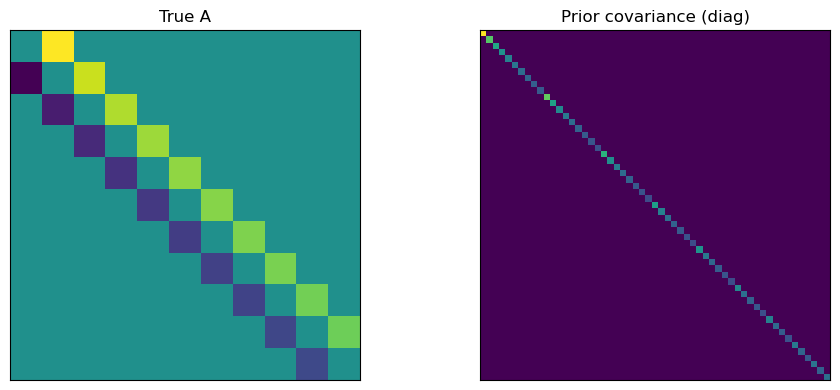

In [20]:
# Visualize the true A and the prior covariance in one figure.
A_plot = A_true if A_true is not None else skew_from_params(dim, a_true)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(A_plot, cmap='viridis')
axes[0].set_title('True A')
axes[1].imshow(CovPriorC3, cmap='viridis')
axes[1].set_title('Prior covariance (diag)')
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()

print('First 25 true parameters:', a_true[:20])

## Estimation
We initialize at a prior draw from the data generator, then run ESS and MESS. Diagnostics below use the selected chain only.

In [21]:
# ESS and MESS estimation from the same initialization.
from pathlib import Path
import pickle

def compute_msjd(chain):
    jumps = np.diff(chain, axis=0)
    return np.mean(jumps * jumps, axis=0)

cache_dir = Path(FileNmBase)
cache_dir.mkdir(parents=True, exist_ok=True)
cache_path = cache_dir / "estimation_first.pkl"

if cache_path.exists():
    with cache_path.open("rb") as handle:
        cache = pickle.load(handle)
    chain_ess = cache["chain_ess"]
    chain_mess = cache["chain_mess"]
    # chain_mess_20 = cache["chain_mess_20"]
    # chain_mess_lp10 = cache["chain_mess_lp10"]
    # chain_mess_lp20 = cache["chain_mess_lp20"]
    chain_mh = cache["chain_mh"]
    acc_mh = cache["acc_mh"]
    runtimes_sec = cache["runtimes_sec"]
    print(f"Loaded cached estimations from {cache_path}")
else:
    runtimes_sec = {}

    rng = np.random.default_rng(seed_mcmc)
    chain_ess = np.zeros((n_iters_ess + 1, x0.shape[0]))
    chain_ess[0] = x0.copy()
    x = x0.copy()
    t0 = time.perf_counter()
    for t in range(n_iters_ess):
        x, _, _ = ess_step(x, problem, rng)
        chain_ess[t + 1] = x
    t1 = time.perf_counter()
    runtimes_sec["ESS"] = t1 - t0

    rng = np.random.default_rng(seed_mcmc)
    chain_mess = np.zeros((n_iters_ess + 1, x0.shape[0]))
    chain_mess[0] = x0.copy()
    x = x0.copy()
    t0 = time.perf_counter()
    for t in range(n_iters_ess):
        x, _, _ = mess_step(x, problem, rng, M=10)
        chain_mess[t + 1] = x
    t1 = time.perf_counter()
    runtimes_sec["MESS10"] = t1 - t0

    # rng = np.random.default_rng(seed_mcmc)
    # chain_mess_20 = np.zeros((n_iters_ess + 1, x0.shape[0]))
    # chain_mess_20[0] = x0.copy()
    # x = x0.copy()
    # t0 = time.perf_counter()
    # for t in range(n_iters_ess):
    #     x, _, _ = mess_step(x, problem, rng, M=20)
    #     chain_mess_20[t + 1] = x
    # t1 = time.perf_counter()
    # runtimes_sec["MESS20"] = t1 - t0

    # rng = np.random.default_rng(seed_mcmc)
    # chain_mess_lp10 = np.zeros((n_iters_ess + 1, x0.shape[0]))
    # chain_mess_lp10[0] = x0.copy()
    # x = x0.copy()
    # t0 = time.perf_counter()
    # for t in range(n_iters_ess):
    #     x, _, _ = mess_step(x, problem, rng, M=10, use_lp=True, distance_metric="angular", lam=0.0)
    #     chain_mess_lp10[t + 1] = x
    # t1 = time.perf_counter()
    # runtimes_sec["MESS_LP10"] = t1 - t0

    # rng = np.random.default_rng(seed_mcmc)
    # chain_mess_lp20 = np.zeros((n_iters_ess + 1, x0.shape[0]))
    # chain_mess_lp20[0] = x0.copy()
    # x = x0.copy()
    # t0 = time.perf_counter()
    # for t in range(n_iters_ess):
    #     x, _, _ = mess_step(x, problem, rng, M=20, use_lp=True, distance_metric="angular", lam=0.0)
    #     chain_mess_lp20[t + 1] = x
    # t1 = time.perf_counter()
    # runtimes_sec["MESS_LP20"] = t1 - t0

    # mPCN chain for overlay plots (same length as ESS/MESS).
    # rng = np.random.default_rng(seed_mcmc)
    # t0 = time.perf_counter()
    # chain_mpcn = mpcn_chain(x0, problem, rng, n_iters_ess, rho=rho, n_props=pMP)
    # t1 = time.perf_counter()
    # runtimes_sec["mPCN"] = t1 - t0

    # MH chain for overlay plots (same length as ESS/MESS).
    rng = np.random.default_rng(seed_mcmc)
    t0 = time.perf_counter()
    chain_mh, acc_mh = mh_chain(x0, problem, rng, n_iters_ess, proposal_std=mh_proposal_std)
    t1 = time.perf_counter()
    runtimes_sec["MH"] = t1 - t0

    cache = {
        "chain_ess": chain_ess,
        "chain_mess": chain_mess,
        # "chain_mess_20": chain_mess_20,
        # "chain_mess_lp10": chain_mess_lp10,
        # "chain_mess_lp20": chain_mess_lp20,
        "chain_mh": chain_mh,
        "acc_mh": acc_mh,
        "runtimes_sec": runtimes_sec,
    }
    with cache_path.open("wb") as handle:
        pickle.dump(cache, handle)
    print(f"Saved cached estimations to {cache_path}")

print("Estimation hyperparameters:")
print({
    "seed_mcmc": seed_mcmc,
    "n_iters_ess": n_iters_ess,
    "mess_M": mess_M,
    "burn_in": burn_in,
    "thin": thin,
    "mh_proposal_std": mh_proposal_std,
})
print("Runtimes (sec):", runtimes_sec)
print("MH acceptance:", acc_mh)

Saved cached estimations to /Users/guillers/Documents/GitHub/multiproposal/estimations/Test_Problems/Experiment_C/Ex_ID_2/seed_0/estimation_first.pkl
Estimation hyperparameters:
{'seed_mcmc': 0, 'n_iters_ess': 50000, 'mess_M': 10, 'burn_in': 5000, 'thin': 1, 'mh_proposal_std': 0.0092}
Runtimes (sec): {'ESS': 12.952323916993919, 'MESS10': 21.790091292001307, 'MH': 4.273383249994367}
MH acceptance: 0.6965


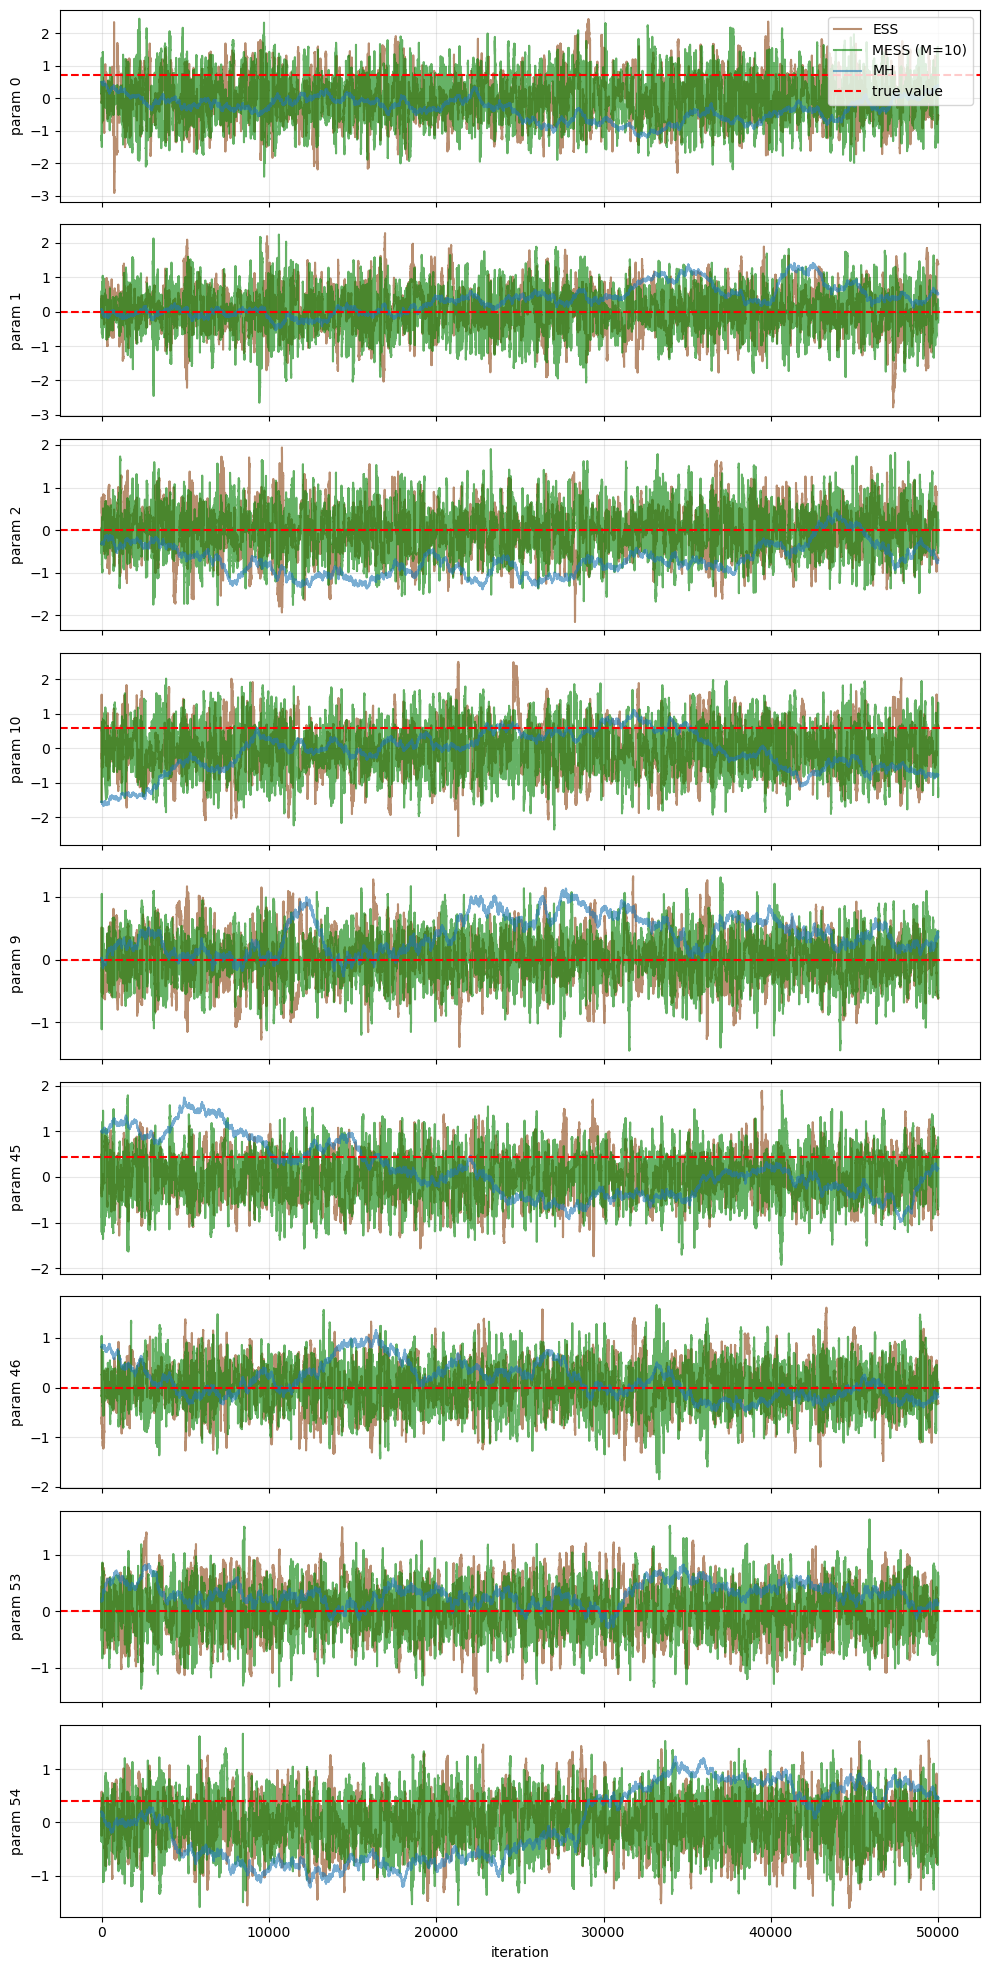

In [22]:
# Overlay trace plots for ESS/MESS/mPCN/MH on the same components.
trace_components = comps
trace_colors = {
    "ess": "saddlebrown",
    "mess10": "green",
    "mess20": "teal",
    "messlp10": "darkorange",
    "messlp20": "slateblue",
    "mh": "tab:blue",
}

fig, axes = plt.subplots(len(trace_components), 1, figsize=(10, 2.2 * len(trace_components)), sharex=True)
if len(trace_components) == 1:
    axes = [axes]
for ax, comp in zip(axes, trace_components):
    ax.plot(chain_ess[:, comp], color=trace_colors["ess"], alpha=0.6, label="ESS")
    ax.plot(chain_mess[:, comp], color=trace_colors["mess10"], alpha=0.6, label="MESS (M=10)")
    # ax.plot(chain_mess_20[:, comp], color=trace_colors["mess20"], alpha=0.6, label="MESS (M=20)")
    # ax.plot(chain_mess_lp10[:, comp], color=trace_colors["messlp10"], alpha=0.6, label="MESS-LP ang (M=10)")
    # ax.plot(chain_mess_lp20[:, comp], color=trace_colors["messlp20"], alpha=0.6, label="MESS-LP ang (M=20)")
    ax.plot(chain_mh[:, comp], color=trace_colors["mh"], alpha=0.6, label="MH")
    ax.axhline(a_true[comp], color='red', linestyle='--', label='true value')
    ax.set_ylabel(f"param {comp}")
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("iteration")
axes[0].legend(loc="upper right")
plt.tight_layout()


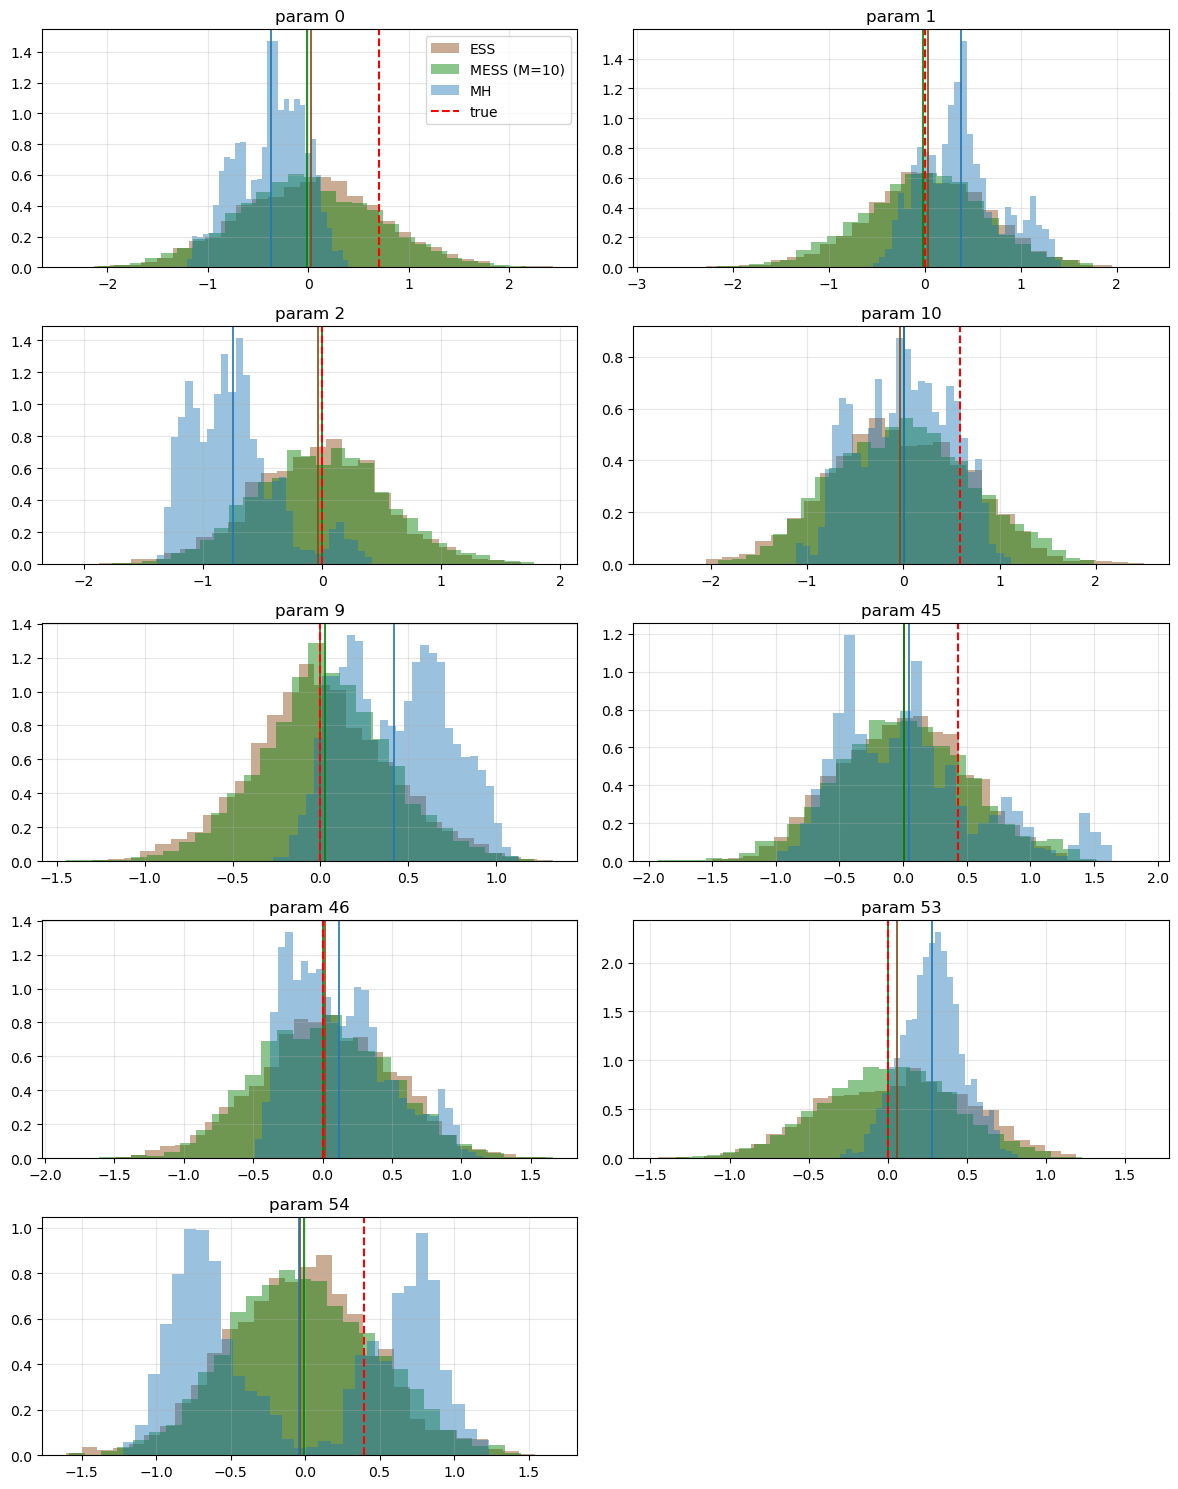

In [23]:
# Overlay posterior histograms for selected components vs. true values.
post_chain_ess = chain_ess[burn_in::thin]
post_chain_mess = chain_mess[burn_in::thin]
# post_chain_mess_20 = chain_mess_20[burn_in::thin]
# post_chain_mess_lp10 = chain_mess_lp10[burn_in::thin]
# post_chain_mess_lp20 = chain_mess_lp20[burn_in::thin]
post_chain_mh = chain_mh[burn_in::thin]

n_comp = len(comps)
n_cols = 2
n_rows = int(np.ceil(n_comp / n_cols))
hist_colors = {
    "ess": "saddlebrown",
    "mess10": "green",
    "mess20": "teal",
    "messlp10": "darkorange",
    "messlp20": "slateblue",
    "mh": "tab:blue",
}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3 * n_rows))
axes = np.array(axes).reshape(-1)
for idx, comp in enumerate(comps):
    ax = axes[idx]
    ax.hist(post_chain_ess[:, comp], bins=30, density=True, alpha=0.45, color=hist_colors["ess"], label="ESS")
    ax.hist(post_chain_mess[:, comp], bins=30, density=True, alpha=0.45, color=hist_colors["mess10"], label="MESS (M=10)")
    # ax.hist(post_chain_mess_20[:, comp], bins=30, density=True, alpha=0.45, color=hist_colors["mess20"], label="MESS (M=20)")
    # ax.hist(post_chain_mess_lp10[:, comp], bins=30, density=True, alpha=0.45, color=hist_colors["messlp10"], label="MESS-LP ang (M=10)")
    # ax.hist(post_chain_mess_lp20[:, comp], bins=30, density=True, alpha=0.45, color=hist_colors["messlp20"], label="MESS-LP ang (M=20)")
    ax.hist(post_chain_mh[:, comp], bins=30, density=True, alpha=0.45, color=hist_colors["mh"], label="MH")
    ax.axvline(np.mean(post_chain_ess[:, comp]), color=hist_colors["ess"], linewidth=1.2)
    ax.axvline(np.mean(post_chain_mess[:, comp]), color=hist_colors["mess10"], linewidth=1.2)
    # ax.axvline(np.mean(post_chain_mess_20[:, comp]), color=hist_colors["mess20"], linewidth=1.2)
    # ax.axvline(np.mean(post_chain_mess_lp10[:, comp]), color=hist_colors["messlp10"], linewidth=1.2)
    # ax.axvline(np.mean(post_chain_mess_lp20[:, comp]), color=hist_colors["messlp20"], linewidth=1.2)
    ax.axvline(np.mean(post_chain_mh[:, comp]), color=hist_colors["mh"], linewidth=1.2)
    ax.axvline(a_true[comp], color='red', linestyle='--', label='true')
    ax.set_title(f'param {comp}')
    ax.grid(alpha=0.3)
for ax in axes[n_comp:]:
    ax.axis('off')
axes[0].legend(loc='upper right')
plt.tight_layout()


/var/folders/jw/64vkfdg1407__zgldz2hpjfr0000gn/T/ipykernel_12209/752057257.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


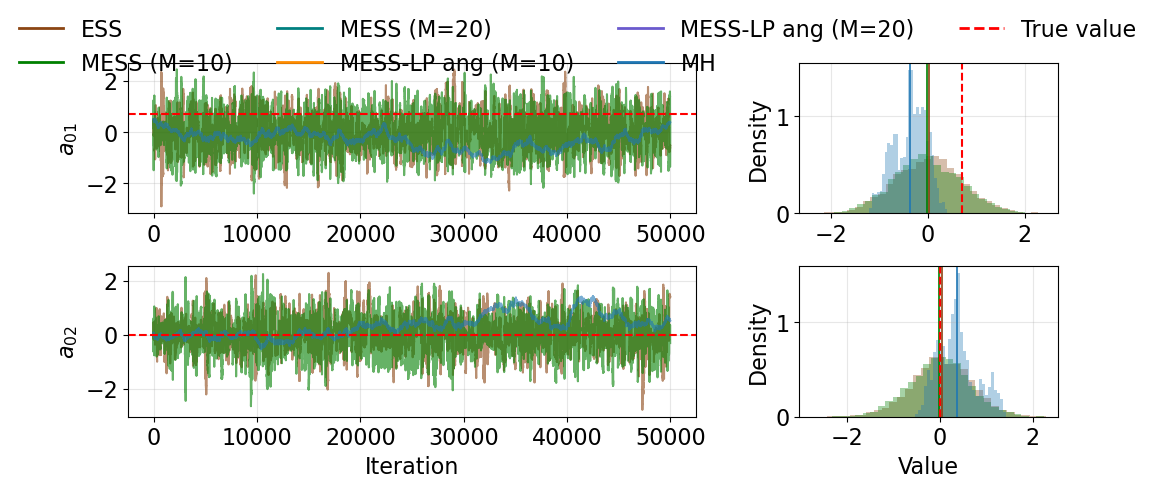

In [24]:
# Trace/hist panel for selected components in comps (all chains).
panel_comps = [0, 1]
trace_colors = {
    "ess": "saddlebrown",
    "mess10": "green",
    "mess20": "teal",
    "messlp10": "darkorange",
    "messlp20": "slateblue",
    "mh": "tab:blue",
}
post_chain_ess = chain_ess[burn_in::thin]
post_chain_mess = chain_mess[burn_in::thin]
# post_chain_mess_20 = chain_mess_20[burn_in::thin]
# post_chain_mess_lp10 = chain_mess_lp10[burn_in::thin]
# post_chain_mess_lp20 = chain_mess_lp20[burn_in::thin]
post_chain_mh = chain_mh[burn_in::thin]
font_size = 16
label_map = {
    0: r"$a_{01}$",
    1: r"$a_{02}$",
    10: r"$a_{12}$",
}

fig, axes = plt.subplots(
    len(panel_comps),
    2,
    figsize=(12, 2.3 * len(panel_comps)),
    gridspec_kw={"width_ratios": [2.2, 1.0], "wspace": 0.25, "hspace": 0.35},
    sharex=False,
    sharey=False,
 )
if len(panel_comps) == 1:
    axes = np.array([axes])

for row_idx, comp in enumerate(panel_comps):
    ax_trace = axes[row_idx, 0]
    ax_hist = axes[row_idx, 1]
    y_label = label_map.get(comp, f"Param {comp}")

    ax_trace.plot(chain_ess[:, comp], color=trace_colors["ess"], alpha=0.6)
    ax_trace.plot(chain_mess[:, comp], color=trace_colors["mess10"], alpha=0.6)
    # ax_trace.plot(chain_mess_20[:, comp], color=trace_colors["mess20"], alpha=0.6)
    # ax_trace.plot(chain_mess_lp10[:, comp], color=trace_colors["messlp10"], alpha=0.6)
    # ax_trace.plot(chain_mess_lp20[:, comp], color=trace_colors["messlp20"], alpha=0.6)
    ax_trace.plot(chain_mh[:, comp], color=trace_colors["mh"], alpha=0.6)
    ax_trace.axhline(a_true[comp], color="red", linestyle="--")
    ax_trace.set_ylabel(y_label, fontsize=font_size)
    ax_trace.grid(alpha=0.3)
    ax_trace.tick_params(labelsize=font_size)
    if row_idx == len(panel_comps) - 1:
        ax_trace.set_xlabel("Iteration", fontsize=font_size)

    ax_hist.hist(post_chain_ess[:, comp], bins=30, density=True, alpha=0.35, color=trace_colors["ess"])
    ax_hist.hist(post_chain_mess[:, comp], bins=30, density=True, alpha=0.35, color=trace_colors["mess10"])
    # ax_hist.hist(post_chain_mess_20[:, comp], bins=30, density=True, alpha=0.35, color=trace_colors["mess20"])
    # ax_hist.hist(post_chain_mess_lp10[:, comp], bins=30, density=True, alpha=0.35, color=trace_colors["messlp10"])
    # ax_hist.hist(post_chain_mess_lp20[:, comp], bins=30, density=True, alpha=0.35, color=trace_colors["messlp20"])
    ax_hist.hist(post_chain_mh[:, comp], bins=30, density=True, alpha=0.35, color=trace_colors["mh"])
    ax_hist.axvline(np.mean(post_chain_ess[:, comp]), color=trace_colors["ess"], linewidth=1.2)
    ax_hist.axvline(np.mean(post_chain_mess[:, comp]), color=trace_colors["mess10"], linewidth=1.2)
    # ax_hist.axvline(np.mean(post_chain_mess_20[:, comp]), color=trace_colors["mess20"], linewidth=1.2)
    # ax_hist.axvline(np.mean(post_chain_mess_lp10[:, comp]), color=trace_colors["messlp10"], linewidth=1.2)
    # ax_hist.axvline(np.mean(post_chain_mess_lp20[:, comp]), color=trace_colors["messlp20"], linewidth=1.2)
    ax_hist.axvline(np.mean(post_chain_mh[:, comp]), color=trace_colors["mh"], linewidth=1.2)
    ax_hist.axvline(a_true[comp], color="red", linestyle="--")
    ax_hist.set_ylabel("Density", fontsize=font_size)
    ax_hist.grid(alpha=0.3)
    ax_hist.tick_params(labelsize=font_size)
    if row_idx == len(panel_comps) - 1:
        ax_hist.set_xlabel("Value", fontsize=font_size)

legend_handles = [
    plt.Line2D([0], [0], color=trace_colors["ess"], lw=2, label="ESS"),
    plt.Line2D([0], [0], color=trace_colors["mess10"], lw=2, label="MESS (M=10)"),
    plt.Line2D([0], [0], color=trace_colors["mess20"], lw=2, label="MESS (M=20)"),
    plt.Line2D([0], [0], color=trace_colors["messlp10"], lw=2, label="MESS-LP ang (M=10)"),
    plt.Line2D([0], [0], color=trace_colors["messlp20"], lw=2, label="MESS-LP ang (M=20)"),
    plt.Line2D([0], [0], color=trace_colors["mh"], lw=2, label="MH"),
    plt.Line2D([0], [0], color="red", lw=2, linestyle="--", label="True value"),
]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    frameon=False,
    fontsize=font_size,
)

plt.tight_layout()
fig.savefig("trace_hist_panel_ad_2comps.png", dpi=400)

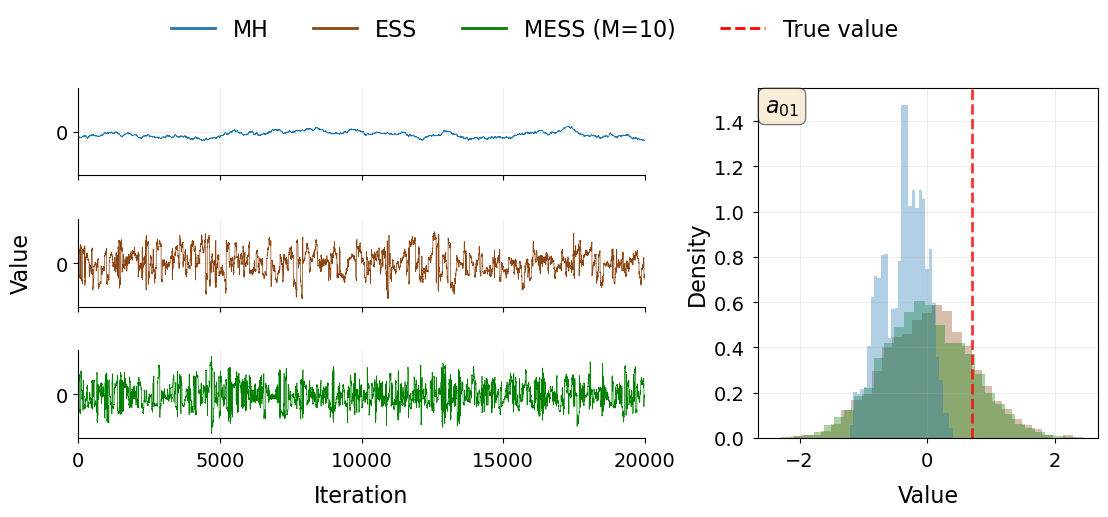

In [25]:
# Trace/hist panel with stacked (separate y-axes) traces on left, histograms on right.
panel_comps = [0]
trace_colors = {
    "ess": "saddlebrown",
    "mess10": "green",
    "mess20": "teal",
    "messlp10": "darkorange",
    "messlp20": "slateblue",
    "mh": "tab:blue",
}
post_chain_ess = chain_ess[burn_in::thin]
post_chain_mess = chain_mess[burn_in::thin]
# post_chain_mess_20 = chain_mess_20[burn_in::thin]
# post_chain_mess_lp10 = chain_mess_lp10[burn_in::thin]
# post_chain_mess_lp20 = chain_mess_lp20[burn_in::thin]
post_chain_mh = chain_mh[burn_in::thin]
font_size = 16
label_map = {
    0: r"$a_{01}$",
    1: r"$a_{02}$",
    10: r"$a_{12}$",
}

# Algorithm definitions
algorithms = [
    ("mh", "MH", trace_colors["mh"]),
    ("ess", "ESS", trace_colors["ess"]),
    ("mess10", "MESS (M=10)", trace_colors["mess10"]),
    # ("mess20", "MESS (M=20)", trace_colors["mess20"]),
    # ("messlp10", "MESS-LP ang (M=10)", trace_colors["messlp10"]),
    # ("messlp20", "MESS-LP ang (M=20)", trace_colors["messlp20"]),
]

chains_dict = {
    "mh": post_chain_mh,
    "ess": post_chain_ess,
    "mess10": post_chain_mess,
    # "mess20": post_chain_mess_20,
    # "messlp10": post_chain_mess_lp10,
    # "messlp20": post_chain_mess_lp20,
}

n_algs = len(algorithms)
n_comps = len(panel_comps)

# Create figure with GridSpec: (n_comps * n_algs) rows, 2 columns
# Left column: stacked traces (each algorithm gets its own y-axis)
# Right column: histograms (1 per component, spanning n_algs rows)
fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(n_comps * n_algs, 2, width_ratios=[2.0, 1.2],
                       wspace=0.25, hspace=0.5)

trace_axes_list = []
axes_by_comp = {}  # To track axes for each component

# Create traces: n_comps components, each with n_algs stacked plots
for comp_idx, comp in enumerate(panel_comps):
    # Get data range for this component across all algorithms
    all_data = [chains_dict[alg_key][:, comp] for alg_key, _, _ in algorithms]
    data_min = np.min([np.min(d) for d in all_data])
    data_max = np.max([np.max(d) for d in all_data])
    data_range = data_max - data_min if data_max != data_min else 1.0
    
    # Create n_algs axes for this component, stacked vertically
    axes_for_comp = []
    for alg_idx, (alg_key, alg_label, color) in enumerate(algorithms):
        row_start = comp_idx * n_algs + alg_idx
        ax_trace = fig.add_subplot(gs[row_start, 0])
        axes_for_comp.append(ax_trace)
        trace_axes_list.append(ax_trace)
        
        # Plot this algorithm's trace
        chain_data = chains_dict[alg_key][:, comp]
        ax_trace.plot(chain_data, color=color, linewidth=0.5 if alg_label != 'MH' else 0.5, label=alg_label)
        
        # Set y-axis range to match all other algorithms for this component
        ax_trace.set_ylim([data_min - 0.05 * data_range, data_max + 0.05 * data_range])
        
        # Set x-axis to show first 50000 iterations
        ax_trace.set_xlim([0, 20000])
        ax_trace.set_xticks(np.arange(0, 20001, 5000))
        
        # Set y-axis to only show 0 label
        ax_trace.set_yticks([0])
        ax_trace.tick_params(labelsize=font_size - 2, axis='y')
        ax_trace.tick_params(labelsize=font_size - 2, axis='x', pad=6)
        
        # Remove top and right spines for cleaner look
        ax_trace.spines['top'].set_visible(False)
        ax_trace.spines['right'].set_visible(False)
        
        # Styling
        ax_trace.grid(alpha=0.2)
        
        # Remove x-label except for last algorithm in this component
        if alg_idx < n_algs - 1:
            ax_trace.set_xticklabels([])
        else:
            ax_trace.set_xlabel("Iteration", fontsize=font_size, labelpad=10)
    
    axes_by_comp[comp] = axes_for_comp

# Add single "Value" label centered for each component's group of plots
for comp_idx, comp in enumerate(panel_comps):
    axes_for_comp = axes_by_comp[comp]
    # Get the middle axis position
    middle_ax = axes_for_comp[n_algs // 2]
    middle_ax.text(-0.1, 0.5, "Value", transform=middle_ax.transAxes,
                    fontsize=font_size, verticalalignment='center', rotation=90,
                    ha='center')

# Create histograms: 1 per component, spanning n_algs rows
for comp_idx, comp in enumerate(panel_comps):
    row_start = comp_idx * n_algs
    ax_hist = fig.add_subplot(gs[row_start:row_start + n_algs, 1])
    
    # Plot overlaid histograms
    ax_hist.hist(post_chain_ess[:, comp], bins=30, density=True, alpha=0.35, color=trace_colors["ess"])
    ax_hist.hist(post_chain_mess[:, comp], bins=30, density=True, alpha=0.35, color=trace_colors["mess10"])
    # ax_hist.hist(post_chain_mess_20[:, comp], bins=30, density=True, alpha=0.35, color=trace_colors["mess20"])
    # ax_hist.hist(post_chain_mess_lp10[:, comp], bins=30, density=True, alpha=0.35, color=trace_colors["messlp10"])
    # ax_hist.hist(post_chain_mess_lp20[:, comp], bins=30, density=True, alpha=0.35, color=trace_colors["messlp20"])
    ax_hist.hist(post_chain_mh[:, comp], bins=30, density=True, alpha=0.35, color=trace_colors["mh"])
    
    # Add true value line (vertical only)
    ax_hist.axvline(a_true[comp], color="red", linestyle="--", linewidth=2, alpha=0.8)
    
    # Styling
    y_label = label_map.get(comp, f"Param {comp}")
    ax_hist.set_ylabel("Density", fontsize=font_size)
    ax_hist.set_xlabel("Value", fontsize=font_size, labelpad=10)
    ax_hist.grid(alpha=0.2)
    ax_hist.tick_params(labelsize=font_size - 2, pad=6)
    ax_hist.text(0.02, 0.98, y_label, transform=ax_hist.transAxes,
                 fontsize=font_size, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Create legend above the plots
legend_handles = [
    plt.Line2D([0], [0], color=trace_colors["mh"], lw=2, label="MH"),
    plt.Line2D([0], [0], color=trace_colors["ess"], lw=2, label="ESS"),
    plt.Line2D([0], [0], color=trace_colors["mess10"], lw=2, label="MESS (M=10)"),
    # plt.Line2D([0], [0], color=trace_colors["mess20"], lw=2, label="MESS (M=20)"),
    # plt.Line2D([0], [0], color=trace_colors["messlp10"], lw=2, label="MESS-LP ang (M=10)"),
    # plt.Line2D([0], [0], color=trace_colors["messlp20"], lw=2, label="MESS-LP ang (M=20)"),
    plt.Line2D([0], [0], color="red", lw=2, linestyle="--", label="True value"),
]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1),
    ncol=4,
    frameon=False,
    fontsize=font_size,
 )

plt.subplots_adjust(left=0.12, right=0.97, top=0.82, bottom=0.12)
fig.savefig("trace_hist_panel_stacked_1comps.png", dpi=400)

Number of samples available (MESS10): 50001


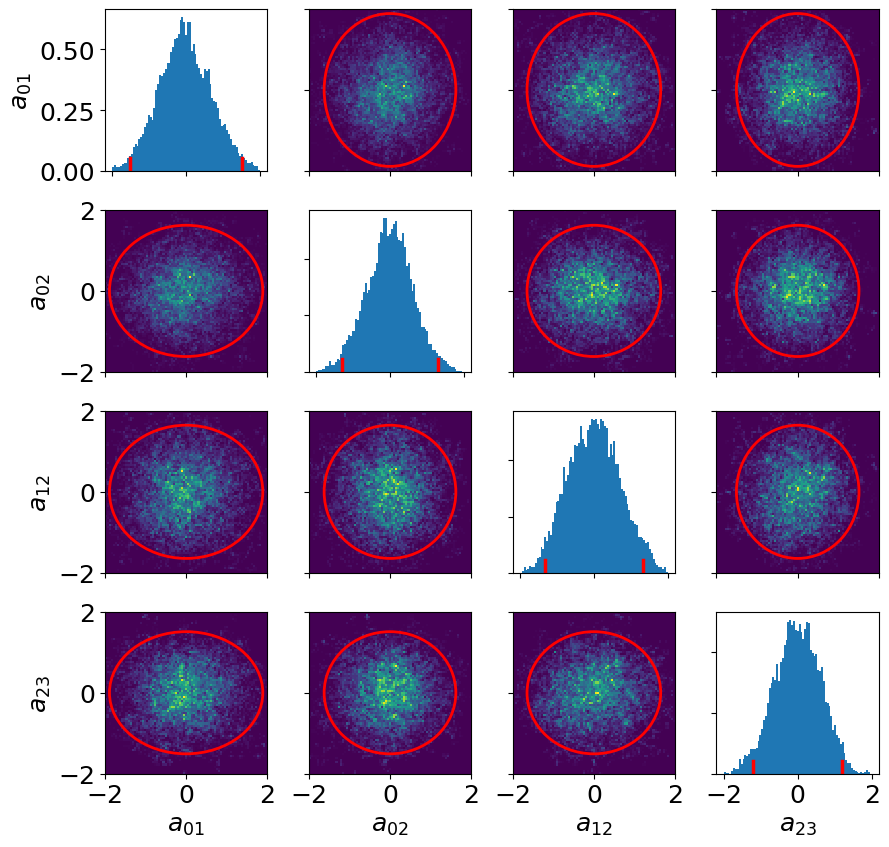

In [26]:
# Persist results and diagnostics for each chain.
panel_comps = [0, 1, 10, 19]
chains = {
    "MESS10": chain_mess,
}

label_map = {
    0: r"$a_{01}$",
    1: r"$a_{02}$",
    10: r"$a_{12}$",
    11: r"$a_{13}$",
    19: r"$a_{23}$",
}
plot_title = "Posterior Marginals and Pairwise Densities"
font_size = 18

# Save runtimes for comparison (seconds).
runtime_file = FileNmBaseData + "runtime_seconds.csv"
with open(runtime_file, "w", encoding="utf-8") as handle:
    handle.write("algorithm,seconds\n")
    for alg, secs in runtimes_sec.items():
        handle.write(f"{alg},{secs:.6f}\n")

for label, est_chain in chains.items():
    est_pot = np.array([-problem.log_likelihood(x) for x in est_chain])
    write_csv(FileNmBaseData + f"exploratory_MCMC_run_{label}.csv", est_chain, new_file=True)
    write_csv(FileNmBaseData + f"exploratory_MCMC_run_Pot_{label}.csv", est_pot[:, None], new_file=True)

    plot_timeseries(est_chain, est_pot, comps, FileNmBase + f"timeseries_{label}.png", label, burn_in)

    numStationarySamps = est_chain.shape[0]
    print(f"Number of samples available ({label}): {numStationarySamps}")

    histFileNm = FileNmBase + f"Baseline_Histogram_{label}.png"
    R = 2 * tau2
    dr = tau2 / 20
    fig = make_hist_grid_comps(
        R,
        dr,
        est_chain,
        panel_comps,
        histFileNm,
        C=CovPriorC3,
        beta=0.95,
        hide_plot=False,
        label_map=label_map,
        font_size=font_size,
        title='',
        figsize=(9, 9)
    )
    fig.savefig('post_marginals_pairwise_dens_testing1.pdf', dpi=600)

## ESS/MSJD and Boxplot Comparisons
We compare posterior spread, effective sample size, and MSJD across ESS, MESS, and mPCN.

Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Mean ESS/min: {'ESS': 2086.0302045701856, 'MESS10': 2667.8384340287103, 'MESS20': 2254.2759910501986, 'MESS_LP10': 276.73134150532366, 'MESS_LP20': 341.96594181942254, 'MH': 939.8469184804188}
Mean ESS: {'ESS': 779.779945980624, 'MESS10': 1759.1160570247814, 'MESS20': 2228.794491208046, 'MESS_LP10': 1720.447876318531, 'MESS_LP20': 2337.9501383143415, 'MH': 132.67631044593404}
Mean MSJD: {'ESS': 0.0005528184278152027, 'MESS10': 0.0014064722301944394, 'MESS20': 0.0018137657907004018, 'MESS_LP10': 0.001433442793043437, 'MESS_LP20': 0.001953720168687851, 'MH': 1.2264760018133956e-05}


/var/folders/jw/64vkfdg1407__zgldz2hpjfr0000gn/T/ipykernel_2074/261705680.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp_raw = ax.boxplot([
/var/folders/jw/64vkfdg1407__zgldz2hpjfr0000gn/T/ipykernel_2074/261705680.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp0 = axes[0].boxplot([
/var/folders/jw/64vkfdg1407__zgldz2hpjfr0000gn/T/ipykernel_2074/261705680.py:128: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[1].boxplot([msjd_ess, msjd_mess, msjd_mess_20, msjd_mess_lp10, msjd_mess_lp20, msjd_mh],


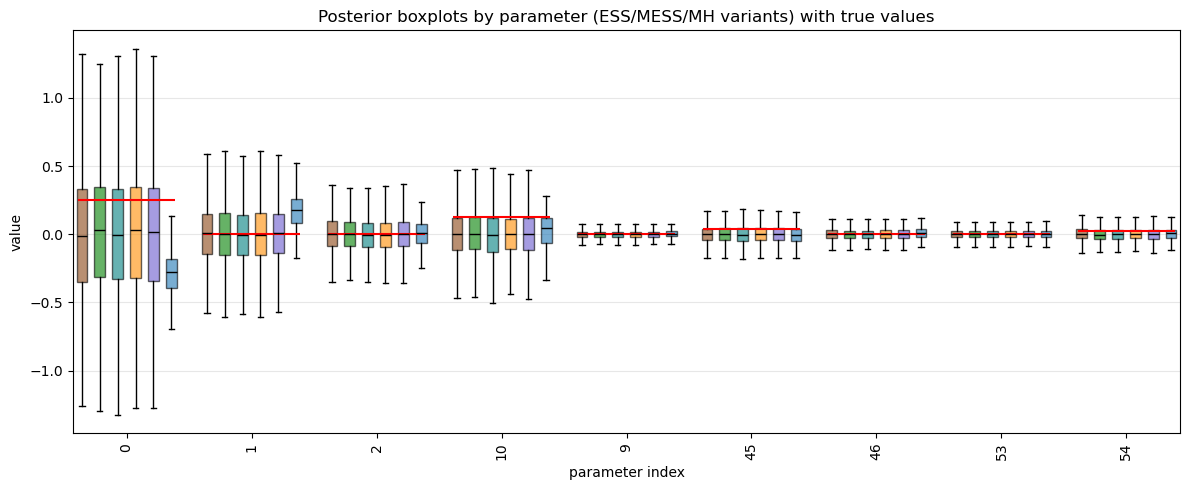

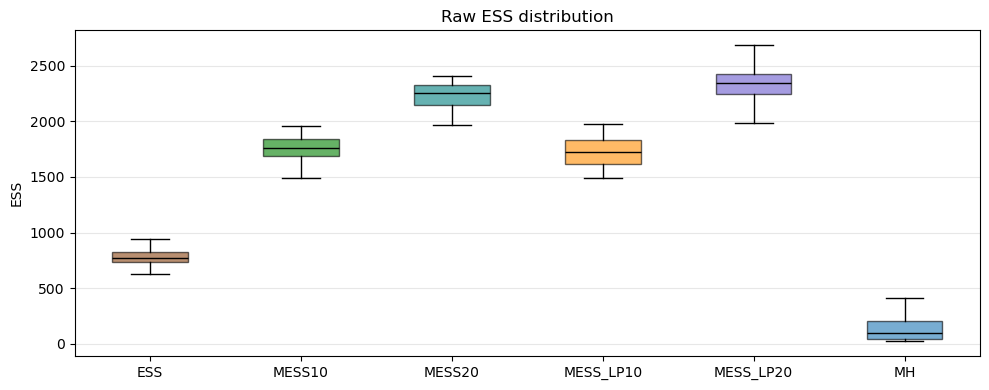

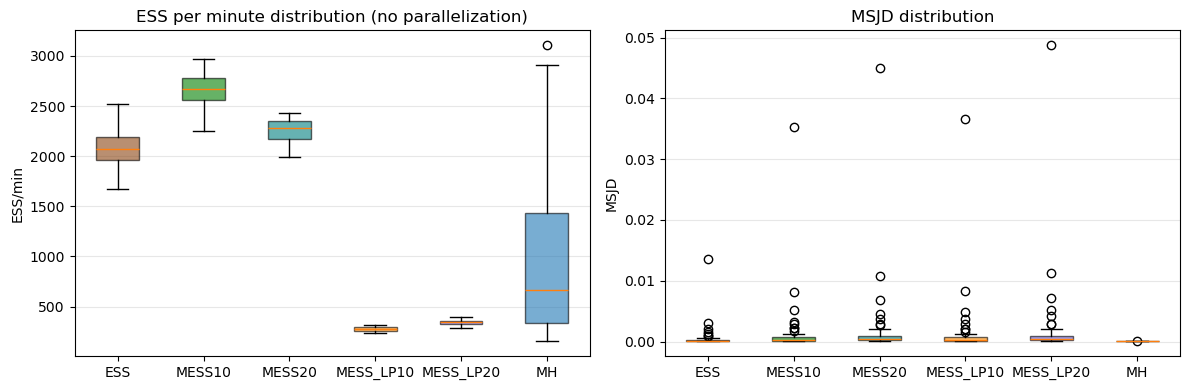

In [13]:
# Boxplots for selected parameters (comps): ESS/MESS/MH side-by-side with true value bars.
param_idx = comps
max_lag = 1500
max_ess_samples = 50000

post_chain_ess = post_chain_ess[:max_ess_samples]
post_chain_mess = post_chain_mess[:max_ess_samples]
post_chain_mess_20 = post_chain_mess_20[:max_ess_samples]
post_chain_mess_lp10 = post_chain_mess_lp10[:max_ess_samples]
post_chain_mess_lp20 = post_chain_mess_lp20[:max_ess_samples]
post_chain_mh = post_chain_mh[:max_ess_samples]

box_data = []
box_positions = []
box_colors = ["saddlebrown", "green", "teal", "darkorange", "slateblue", "tab:blue"]
labels = []
for j, i in enumerate(param_idx):
    box_data.extend([
        post_chain_ess[:, i],
        post_chain_mess[:, i],
        post_chain_mess_20[:, i],
        post_chain_mess_lp10[:, i],
        post_chain_mess_lp20[:, i],
        post_chain_mh[:, i],
    ])
    base = j * 7
    box_positions.extend([base + 0, base + 1, base + 2, base + 3, base + 4, base + 5])
    labels.append(str(i))

fig_w = max(12, 0.7 * len(param_idx))
fig, ax = plt.subplots(figsize=(fig_w, 5))
bp = ax.boxplot(
    box_data,
    positions=box_positions,
    widths=0.6,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "black"},
)
for k, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(box_colors[k % len(box_colors)])
    patch.set_alpha(0.6)
for j, i in enumerate(param_idx):
    ax.hlines(a_true[i], j * 7 - 0.2, j * 7 + 5.2, colors="red", linewidth=1.5)
ax.set_xticks([j * 7 + 2.5 for j in range(len(param_idx))])
ax.set_xticklabels(labels, rotation=90)
ax.set_xlabel("parameter index")
ax.set_ylabel("value")
ax.set_title("Posterior boxplots by parameter (ESS/MESS/MH variants) with true values")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()

# ESS and MSJD by parameter, plus ESS per minute boxplots.
ess_ess = estimate_effective_sample_size(post_chain_ess, max_lag=max_lag)
ess_mess = estimate_effective_sample_size(post_chain_mess, max_lag=max_lag)
ess_mess_20 = estimate_effective_sample_size(post_chain_mess_20, max_lag=max_lag)
ess_mess_lp10 = estimate_effective_sample_size(post_chain_mess_lp10, max_lag=max_lag)
ess_mess_lp20 = estimate_effective_sample_size(post_chain_mess_lp20, max_lag=max_lag)
ess_mh = estimate_effective_sample_size(post_chain_mh, max_lag=max_lag)

msjd_ess = compute_msjd(post_chain_ess)
msjd_mess = compute_msjd(post_chain_mess)
msjd_mess_20 = compute_msjd(post_chain_mess_20)
msjd_mess_lp10 = compute_msjd(post_chain_mess_lp10)
msjd_mess_lp20 = compute_msjd(post_chain_mess_lp20)
msjd_mh = compute_msjd(post_chain_mh)

runtime_min = {k: v / 60.0 for k, v in runtimes_sec.items()}
ess_per_min = {
    "ESS": ess_ess / runtime_min["ESS"],
    "MESS10": ess_mess / runtime_min["MESS10"],
    "MESS20": ess_mess_20 / runtime_min["MESS20"],
    "MESS_LP10": ess_mess_lp10 / runtime_min["MESS_LP10"],
    "MESS_LP20": ess_mess_lp20 / runtime_min["MESS_LP20"],
    "MH": ess_mh / runtime_min["MH"],
}

# Raw ESS (no time normalization).
ess_raw = {
    "ESS": ess_ess,
    "MESS10": ess_mess,
    "MESS20": ess_mess_20,
    "MESS_LP10": ess_mess_lp10,
    "MESS_LP20": ess_mess_lp20,
    "MH": ess_mh,
}

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
bp_raw = ax.boxplot([
    ess_raw["ESS"],
    ess_raw["MESS10"],
    ess_raw["MESS20"],
    ess_raw["MESS_LP10"],
    ess_raw["MESS_LP20"],
    ess_raw["MH"],
],
    labels=["ESS", "MESS10", "MESS20", "MESS_LP10", "MESS_LP20", "MH"],
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "black"},
)
for patch, color in zip(bp_raw["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_title("Raw ESS distribution")
ax.set_ylabel("ESS")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bp0 = axes[0].boxplot([
    ess_per_min["ESS"],
    ess_per_min["MESS10"],
    ess_per_min["MESS20"],
    ess_per_min["MESS_LP10"],
    ess_per_min["MESS_LP20"],
    ess_per_min["MH"],
],
                     labels=["ESS", "MESS10", "MESS20", "MESS_LP10", "MESS_LP20", "MH"],
                     patch_artist=True)
for patch, color in zip(bp0["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_title("ESS per minute distribution (no parallelization)")
axes[0].set_ylabel("ESS/min")
axes[0].grid(alpha=0.3, axis="y")

bp1 = axes[1].boxplot([msjd_ess, msjd_mess, msjd_mess_20, msjd_mess_lp10, msjd_mess_lp20, msjd_mh],
                     labels=["ESS", "MESS10", "MESS20", "MESS_LP10", "MESS_LP20", "MH"],
                     patch_artist=True)
for patch, color in zip(bp1["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_title("MSJD distribution")
axes[1].set_ylabel("MSJD")
axes[1].grid(alpha=0.3, axis="y")
plt.tight_layout()

print("Mean ESS/min:", {k: float(np.mean(v)) for k, v in ess_per_min.items()})
print("Mean ESS:", {k: float(np.mean(v)) for k, v in ess_raw.items()})
print("Mean MSJD:", {
    "ESS": float(np.mean(msjd_ess)),
    "MESS10": float(np.mean(msjd_mess)),
    "MESS20": float(np.mean(msjd_mess_20)),
    "MESS_LP10": float(np.mean(msjd_mess_lp10)),
    "MESS_LP20": float(np.mean(msjd_mess_lp20)),
    "MH": float(np.mean(msjd_mh)),
})

## LP Distance Comparison at $d=11$
We compare MESS with LP using angular vs. Euclidean distance, and a uniform MESS baseline (no LP).

Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Mean ESS: {'Uniform': 812.8806184723016, 'LP angular': 906.4358247591084, 'LP euclidean': 873.2146852064707}
Mean MSJD: {'Uniform': 0.0017377137577781908, 'LP angular': 0.0018096626897834654, 'LP euclidean': 0.001814154598357543}


/var/folders/jw/64vkfdg1407__zgldz2hpjfr0000gn/T/ipykernel_4108/1895823689.py:82: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp_ess = axes[0].boxplot([ess_uniform, ess_lp_ang, ess_lp_euc],
/var/folders/jw/64vkfdg1407__zgldz2hpjfr0000gn/T/ipykernel_4108/1895823689.py:92: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp_msjd = axes[1].boxplot([msjd_uniform, msjd_lp_ang, msjd_lp_euc],


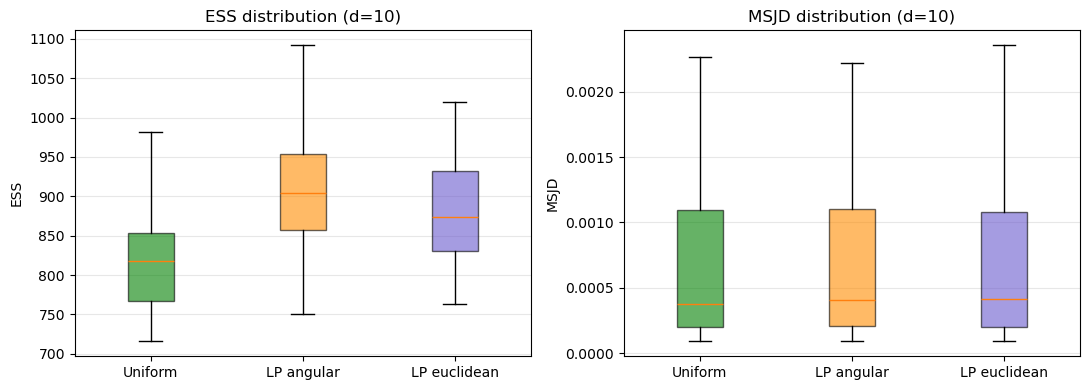

In [ ]:
# Compare MESS-LP (angular vs. euclidean) against uniform MESS at d=10.
d_compare = 11
mess_M_compare = 10
n_iters_compare = n_iters_ess
burn_in_compare = burn_in
max_lag_compare = max_lag

obs_scale_compare = max(3, min(d_compare - 1, 7))
data_slice_start_compare = obs_scale_compare - 3
data_slice_end_compare = obs_scale_compare - 1
obs_indices_compare = np.arange(data_slice_start_compare, data_slice_end_compare, dtype=int)

data_compare = generate_advection_diffusion_data(
    dim=d_compare,
    kappa=kappa,
    sigma=sigma,
    obs_indices=obs_indices_compare,
    alpha=alpha,
    gamma=gamma,
    tau2=tau2,
    a_mode=a_mode,
    seed=seed_data,
 )
problem_compare = AdvectionDiffusionToy(
    dim=d_compare,
    kappa=kappa,
    sigma=sigma,
    y=data_compare['y'],
    obs_indices=obs_indices_compare,
    g=data_compare['g'],
    prior_diag=data_compare['prior_diag'],
 )
x0_compare = data_compare['a_init']

# Uniform MESS (lp=False).
rng = np.random.default_rng(seed_mcmc)
chain_mess_uniform = np.zeros((n_iters_compare + 1, x0_compare.shape[0]))
chain_mess_uniform[0] = x0_compare.copy()
x = x0_compare.copy()
for t in range(n_iters_compare):
    x, _, _ = mess_step(x, problem_compare, rng, M=mess_M_compare, use_lp=False)
    chain_mess_uniform[t + 1] = x

# MESS-LP (angular distance).
rng = np.random.default_rng(seed_mcmc)
chain_mess_lp_ang = np.zeros((n_iters_compare + 1, x0_compare.shape[0]))
chain_mess_lp_ang[0] = x0_compare.copy()
x = x0_compare.copy()
for t in range(n_iters_compare):
    x, _, _ = mess_step(
        x, problem_compare, rng, M=mess_M_compare, use_lp=True, distance_metric="angular", lam=0.0
    )
    chain_mess_lp_ang[t + 1] = x

# MESS-LP (euclidean distance).
rng = np.random.default_rng(seed_mcmc)
chain_mess_lp_euc = np.zeros((n_iters_compare + 1, x0_compare.shape[0]))
chain_mess_lp_euc[0] = x0_compare.copy()
x = x0_compare.copy()
for t in range(n_iters_compare):
    x, _, _ = mess_step(
        x, problem_compare, rng, M=mess_M_compare, use_lp=True, distance_metric="euclidean", lam=0.0
    )
    chain_mess_lp_euc[t + 1] = x

# ESS/MSJD distributions across parameters.
post_uniform = chain_mess_uniform[burn_in_compare::thin]
post_lp_ang = chain_mess_lp_ang[burn_in_compare::thin]
post_lp_euc = chain_mess_lp_euc[burn_in_compare::thin]

ess_uniform = estimate_effective_sample_size(post_uniform, max_lag=max_lag_compare)
ess_lp_ang = estimate_effective_sample_size(post_lp_ang, max_lag=max_lag_compare)
ess_lp_euc = estimate_effective_sample_size(post_lp_euc, max_lag=max_lag_compare)

msjd_uniform = compute_msjd(post_uniform)
msjd_lp_ang = compute_msjd(post_lp_ang)
msjd_lp_euc = compute_msjd(post_lp_euc)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
box_colors = ["green", "darkorange", "slateblue"]

bp_ess = axes[0].boxplot([ess_uniform, ess_lp_ang, ess_lp_euc],
                          labels=["Uniform", "LP angular", "LP euclidean"],
                          patch_artist=True, showfliers=False)
for patch, color in zip(bp_ess["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_title("ESS distribution (d=11)")
axes[0].set_ylabel("ESS")
axes[0].grid(alpha=0.3, axis="y")

bp_msjd = axes[1].boxplot([msjd_uniform, msjd_lp_ang, msjd_lp_euc],
                           labels=["Uniform", "LP angular", "LP euclidean"],
                           patch_artist=True, showfliers=False)
for patch, color in zip(bp_msjd["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_title("MSJD distribution (d=10)")
axes[1].set_ylabel("MSJD")
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()

print("Mean ESS:", {
    "Uniform": float(np.mean(ess_uniform)),
    "LP angular": float(np.mean(ess_lp_ang)),
    "LP euclidean": float(np.mean(ess_lp_euc)),
})
print("Mean MSJD:", {
    "Uniform": float(np.mean(msjd_uniform)),
    "LP angular": float(np.mean(msjd_lp_ang)),
    "LP euclidean": float(np.mean(msjd_lp_euc)),
})

### Summary Tables and M Sweep
This builds summary tables (mean and 95% credible intervals) for ESS and MSJD, and repeats the LP comparison for multiple $M$ values.

In [14]:
# Summary tables for ESS/MSJD with multiple M values (with caching).
M_list = [5, 10, 20, 50]
n_iters_m_sweep = 10000  # Change this to higher values (e.g., 100000) and rerun with force_recompute=True
force_recompute = False  # Set to True to overwrite cached results

cache_m_sweep_path = Path(FileNmBase) / "m_sweep_results.pkl"

# Set up problem for d=11 if not already defined (for M sweep).
if 'x0_compare' not in locals() or 'problem_compare' not in locals():
    d_compare = 11
    mess_M_compare = 10
    n_iters_compare = 10000
    burn_in_compare = 1000
    max_lag_compare = max_lag if 'max_lag' in locals() else 500
    
    obs_scale_compare = max(3, min(d_compare - 1, 7))
    data_slice_start_compare = obs_scale_compare - 3
    data_slice_end_compare = obs_scale_compare - 1
    obs_indices_compare = np.arange(data_slice_start_compare, data_slice_end_compare, dtype=int)
    
    data_compare = generate_advection_diffusion_data(
        dim=d_compare,
        kappa=kappa,
        sigma=sigma,
        obs_indices=obs_indices_compare,
        alpha=alpha,
        gamma=gamma,
        tau2=tau2,
        a_mode=a_mode,
        seed=seed_data,
    )
    problem_compare = AdvectionDiffusionToy(
        dim=d_compare,
        kappa=kappa,
        sigma=sigma,
        y=data_compare['y'],
        obs_indices=obs_indices_compare,
        g=data_compare['g'],
        prior_diag=data_compare['prior_diag'],
    )
    x0_compare = data_compare['a_init']

def summarize_distribution(values):
    mean_val = float(np.mean(values))
    lo, hi = np.quantile(values, [0.025, 0.975])
    return mean_val, float(lo), float(hi)

def run_mess_variant(M, use_lp, distance_metric=None, n_iters=n_iters_m_sweep):
    rng = np.random.default_rng(seed_mcmc)
    chain = np.zeros((n_iters + 1, x0_compare.shape[0]))
    chain[0] = x0_compare.copy()
    x = x0_compare.copy()
    for t in range(n_iters):
        if use_lp:
            x, _, _ = mess_step(
                x, problem_compare, rng, M=M, use_lp=True, distance_metric=distance_metric, lam=0.0
            )
        else:
            x, _, _ = mess_step(x, problem_compare, rng, M=M, use_lp=False)
        chain[t + 1] = x
    burn_in_m = int(0.2 * n_iters)  # 20% burn-in
    post = chain[burn_in_m::thin]
    ess_vals = estimate_effective_sample_size(post, max_lag=max_lag_compare)
    msjd_vals = compute_msjd(post)
    return ess_vals, msjd_vals

if cache_m_sweep_path.exists() and not force_recompute:
    with cache_m_sweep_path.open("rb") as handle:
        cache_m_sweep = pickle.load(handle)
    rows_ess = cache_m_sweep["rows_ess"]
    rows_msjd = cache_m_sweep["rows_msjd"]
    print(f"Loaded M-sweep results from cache: {cache_m_sweep_path}")
else:
    rows_ess = []
    rows_msjd = []
    for M in M_list:
        print(f"Running M={M}...", end=" ")
        ess_uniform_M, msjd_uniform_M = run_mess_variant(M, use_lp=False)
        ess_ang_M, msjd_ang_M = run_mess_variant(M, use_lp=True, distance_metric="angular")
        ess_euc_M, msjd_euc_M = run_mess_variant(M, use_lp=True, distance_metric="euclidean")

        rows_ess.append((f"Uniform (M={M})",) + summarize_distribution(ess_uniform_M))
        rows_ess.append((f"LP angular (M={M})",) + summarize_distribution(ess_ang_M))
        rows_ess.append((f"LP euclidean (M={M})",) + summarize_distribution(ess_euc_M))

        rows_msjd.append((f"Uniform (M={M})",) + summarize_distribution(msjd_uniform_M))
        rows_msjd.append((f"LP angular (M={M})",) + summarize_distribution(msjd_ang_M))
        rows_msjd.append((f"LP euclidean (M={M})",) + summarize_distribution(msjd_euc_M))
        print("Done.")

    cache_m_sweep = {
        "rows_ess": rows_ess,
        "rows_msjd": rows_msjd,
        "n_iters": n_iters_m_sweep,
        "M_list": M_list,
    }
    with cache_m_sweep_path.open("wb") as handle:
        pickle.dump(cache_m_sweep, handle)
    print(f"Saved M-sweep results to cache: {cache_m_sweep_path}")

def print_table(rows, title):
    headers = ["Method", "Mean", "CI 2.5%", "CI 97.5%"]
    col_widths = [max(len(r[0]) for r in rows + [(headers[0], 0, 0, 0)])]
    col_widths += [len(h) for h in headers[1:]]
    print(title)
    print(f"{headers[0]:<{col_widths[0]}}  {headers[1]:>10}  {headers[2]:>10}  {headers[3]:>10}")
    print("-" * (col_widths[0] + 34))
    for method, mean_val, lo, hi in rows:
        print(f"{method:<{col_widths[0]}}  {mean_val:>10.4f}  {lo:>10.4f}  {hi:>10.4f}")
    print("")

print_table(rows_ess, "ESS summary (mean and 95% CI)")
print_table(rows_msjd, "MSJD summary (mean and 95% CI)")

Loaded M-sweep results from cache: /Users/guillers/Documents/GitHub/multiproposal/estimations/Test_Problems/Experiment_C/Ex_ID_1/m_sweep_results.pkl
ESS summary (mean and 95% CI)
Method                     Mean     CI 2.5%    CI 97.5%
-----------------------------------------------------
Uniform (M=5)          184.5436    132.3806    238.6958
LP angular (M=5)       219.0974    157.5435    290.6424
LP euclidean (M=5)     218.2905    168.9173    280.8207
Uniform (M=10)         296.1983    220.6017    375.8673
LP angular (M=10)      300.7370    201.3975    387.8600
LP euclidean (M=10)    281.2339    197.5595    345.9572
Uniform (M=20)         352.6765    253.8400    461.0469
LP angular (M=20)      407.3804    316.3294    508.2354
LP euclidean (M=20)    402.1465    315.3662    490.6232
Uniform (M=50)         530.3995    408.7642    670.3461
LP angular (M=50)      532.0294    422.6685    623.6150
LP euclidean (M=50)    528.0282    407.1988    632.6549

MSJD summary (mean and 95% CI)
Method 

## ESS vs. $M$ at $d=11$
We run uniform MESS for $M \in \{10, 20, 50, 100, 150, 200, 250\}$ with 10,000 iterations each, then plot mean ESS versus $M$.

Loaded ESS vs M curve from cache: /Users/guillers/Documents/GitHub/multiproposal/estimations/Test_Problems/Experiment_C/Ex_ID_1/ess_vs_m_curve_d11.pkl


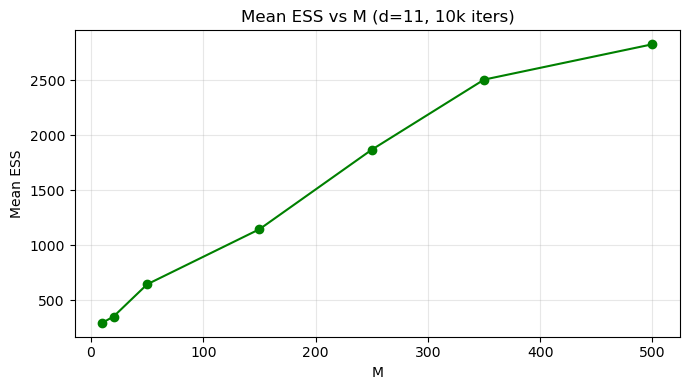

In [108]:
# ESS vs M curve for d=11 (uniform MESS) with caching.
from pathlib import Path
import pickle

d_curve = 11
M_values_curve = [10, 20, 50, 150, 250, 350, 500]
n_iters_curve_list = [10000, 10000, 12000, 20000, 30000, 40000, 50000]
burn_in_frac_curve = 0.2
max_lag_curve = max_lag_compare if "max_lag_compare" in locals() else 500
force_recompute_curve = False
cache_curve_path = Path(FileNmBase) / "ess_vs_m_curve_d11.pkl"

# Ensure the d=11 problem is available.
if "problem_compare" not in locals() or getattr(problem_compare, "dim", None) != d_curve:
    obs_scale_curve = max(3, min(d_curve - 1, 7))
    data_slice_start_curve = obs_scale_curve - 3
    data_slice_end_curve = obs_scale_curve - 1
    obs_indices_curve = np.arange(data_slice_start_curve, data_slice_end_curve, dtype=int)

    data_curve = generate_advection_diffusion_data(
        dim=d_curve,
        kappa=kappa,
        sigma=sigma,
        obs_indices=obs_indices_curve,
        alpha=alpha,
        gamma=gamma,
        tau2=tau2,
        a_mode=a_mode,
        seed=seed_data,
    )
    problem_compare = AdvectionDiffusionToy(
        dim=d_curve,
        kappa=kappa,
        sigma=sigma,
        y=data_curve["y"],
        obs_indices=obs_indices_curve,
        g=data_curve["g"],
        prior_diag=data_curve["prior_diag"],
    )
    x0_compare = data_curve["a_init"]

if cache_curve_path.exists() and not force_recompute_curve:
    with cache_curve_path.open("rb") as handle:
        cache_curve = pickle.load(handle)
    ess_means_curve = cache_curve["ess_means_curve"]
    M_values_curve = cache_curve["M_values_curve"]
    print(f"Loaded ESS vs M curve from cache: {cache_curve_path}")
else:
    ess_means_curve = []
    for ind_M in np.arange(len(M_values_curve)):
        M = M_values_curve[ind_M]
        n_iters_curve = n_iters_curve_list[ind_M]
        burn_in_curve = int(burn_in_frac_curve * n_iters_curve)
        rng = np.random.default_rng(seed_mcmc)
        chain = np.zeros((n_iters_curve + 1, x0_compare.shape[0]))
        chain[0] = x0_compare.copy()
        x = x0_compare.copy()
        for t in range(n_iters_curve):
            x, _, _ = mess_step(x, problem_compare, rng, M=M, use_lp=False)
            chain[t + 1] = x
        post = chain[burn_in_curve::thin]
        ess_vals = estimate_effective_sample_size(post, max_lag=max_lag_curve)
        ess_means_curve.append(float(np.mean(ess_vals)/n_iters_curve))
        print(f"M={M:>3d} mean ESS={ess_means_curve[-1]:.3f}")

    cache_curve = {
        "d_curve": d_curve,
        "M_values_curve": M_values_curve,
        "n_iters_curve": n_iters_curve,
        "burn_in_frac_curve": burn_in_frac_curve,
        "max_lag_curve": max_lag_curve,
        "ess_means_curve": ess_means_curve,
    }
    with cache_curve_path.open("wb") as handle:
        pickle.dump(cache_curve, handle)
    print(f"Saved ESS vs M curve to cache: {cache_curve_path}")

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(M_values_curve, ess_means_curve, marker="o", color="green")
ax.set_xlabel("M")
ax.set_ylabel("Mean ESS")
ax.set_title("Mean ESS vs M (d=11, 10k iters)")
ax.grid(alpha=0.3)
plt.tight_layout()

In [107]:
# Generate LaTeX table for ESS and MSJD results (M = 5, 10, 50 only)
import numpy as np

# Organize data by M value
data_by_M = {}
for row in rows_ess:
    method, mean, lo, hi = row
    M_val = int(method.split('M=')[1].rstrip(')'))
    distance = ' '.join(method.split()[:-1])
    
    if M_val not in data_by_M:
        data_by_M[M_val] = {'ess': {}, 'msjd': {}}
    
    data_by_M[M_val]['ess'][distance] = (mean, lo, hi)

for row in rows_msjd:
    method, mean, lo, hi = row
    M_val = int(method.split('M=')[1].rstrip(')'))
    distance = ' '.join(method.split()[:-1])
    
    data_by_M[M_val]['msjd'][distance] = (mean, lo, hi)

# Filter M values to only include 5, 10, 50
M_values = [5, 10, 50]

# Generate LaTeX table with ESS and MSJD subtables
latex_code = r"""\begin{table}[h]
\centering
\small
"""

# ESS Table
latex_code += r"""
\begin{tabular}{l|ccc}
\toprule
\multicolumn{4}{c}{\textbf{ESS}} \\
$M$ & Uniform & LP Angular & LP Euclidean \\
\midrule
"""

for M in M_values:
    if M in data_by_M:
        ess_data = data_by_M[M]['ess']
        
        # Format ESS values
        ess_uniform = f"{ess_data['Uniform'][0]:.3f} ({ess_data['Uniform'][1]:.3f}, {ess_data['Uniform'][2]:.3f})"
        ess_angular = f"{ess_data['LP angular'][0]:.3f} ({ess_data['LP angular'][1]:.3f}, {ess_data['LP angular'][2]:.3f})"
        ess_euclidean = f"{ess_data['LP euclidean'][0]:.3f} ({ess_data['LP euclidean'][1]:.3f}, {ess_data['LP euclidean'][2]:.3f})"
        
        latex_code += f"{M} & {ess_uniform} & {ess_angular} & {ess_euclidean} \\\\\n"

latex_code += r"""\bottomrule
\end{tabular}

"""

# MSJD Table
latex_code += r"""
\begin{tabular}{l|ccc}
\toprule
\multicolumn{4}{c}{\textbf{MSJD}} \\
$M$ & Uniform & LP Angular & LP Euclidean \\
\midrule
"""

for M in M_values:
    if M in data_by_M:
        msjd_data = data_by_M[M]['msjd']
        
        # Format MSJD values
        msjd_uniform = f"{msjd_data['Uniform'][0]:.4f} ({msjd_data['Uniform'][1]:.4f}, {msjd_data['Uniform'][2]:.4f})"
        msjd_angular = f"{msjd_data['LP angular'][0]:.4f} ({msjd_data['LP angular'][1]:.4f}, {msjd_data['LP angular'][2]:.4f})"
        msjd_euclidean = f"{msjd_data['LP euclidean'][0]:.4f} ({msjd_data['LP euclidean'][1]:.4f}, {msjd_data['LP euclidean'][2]:.4f})"
        
        latex_code += f"{M} & {msjd_uniform} & {msjd_angular} & {msjd_euclidean} \\\\\n"

latex_code += r"""\bottomrule
\end{tabular}

\caption{ESS and MSJD comparison across MESS variants. Values shown as mean (CI 2.5\%, CI 97.5\%).}
\label{tab:ess_msjd_comparison}
\end{table}"""

print(latex_code)

\begin{table}[h]
\centering
\small

\begin{tabular}{l|ccc}
\toprule
\multicolumn{4}{c}{\textbf{ESS}} \\
$M$ & Uniform & LP Angular & LP Euclidean \\
\midrule
5 & 184.544 (132.381, 238.696) & 219.097 (157.543, 290.642) & 218.291 (168.917, 280.821) \\
10 & 296.198 (220.602, 375.867) & 300.737 (201.397, 387.860) & 281.234 (197.560, 345.957) \\
50 & 530.399 (408.764, 670.346) & 532.029 (422.668, 623.615) & 528.028 (407.199, 632.655) \\
\bottomrule
\end{tabular}


\begin{tabular}{l|ccc}
\toprule
\multicolumn{4}{c}{\textbf{MSJD}} \\
$M$ & Uniform & LP Angular & LP Euclidean \\
\midrule
5 & 0.0009 (0.0000, 0.0047) & 0.0010 (0.0000, 0.0045) & 0.0011 (0.0001, 0.0051) \\
10 & 0.0015 (0.0001, 0.0072) & 0.0013 (0.0001, 0.0059) & 0.0012 (0.0001, 0.0063) \\
50 & 0.0025 (0.0001, 0.0135) & 0.0024 (0.0001, 0.0108) & 0.0024 (0.0001, 0.0142) \\
\bottomrule
\end{tabular}

\caption{ESS and MSJD comparison across MESS variants. Values shown as mean (CI 2.5\%, CI 97.5\%).}
\label{tab:ess_msjd_comparison}
\en

## Dimension Sweep
We compare ESS and MSJD as a function of the model dimension $d$.

In [115]:
# Dimension sweep for d in {10, 15, 20, 25, 30} with cached results (uniform MESS only).
from pathlib import Path
import pickle
import time

d_list = [10, 15, 20, 25, 30]
M_list = [10, 20, 50, 100, 200, 300]
n_iters_dim = 200000
burn_in_frac = 0.1
max_lag = 1500

# MH proposal stds per d (from the M=d sweep).
mh_proposal_stds_scaled = [0.012, 0.005, 0.0035, 0.001, 0.0009]
if len(mh_proposal_stds_scaled) != len(d_list):
    raise ValueError("mh_proposal_stds_scaled must match d_list length")

force_recompute_mess = False
force_recompute_mh = True

# Use Ex_ID_1 subdirectory
exp_cache_dir = Path(FileNmBase) / "Ex_ID_1"
exp_cache_dir.mkdir(parents=True, exist_ok=True)

mess_cache_path = exp_cache_dir / "dim_sweep_mess_uniform_M.pkl"
mh_cache_path = exp_cache_dir / "dim_sweep_mh.pkl"
mess_chains_cache_path = exp_cache_dir / "dim_sweep_mess_chains.pkl"
mh_chains_cache_path = exp_cache_dir / "dim_sweep_mh_chains.pkl"

ess_by_M = {M: [] for M in M_list}
msjd_by_M = {M: [] for M in M_list}
ess_mh_by_d = []
msjd_mh_by_d = []
mess_chains_dict = {}
mh_chains_dict = {}

if mess_cache_path.exists():
    with mess_cache_path.open("rb") as handle:
        cache_dim_sweep = pickle.load(handle)
    d_list = cache_dim_sweep["d_list"]
    M_list = cache_dim_sweep["M_list"]
    ess_by_M = cache_dim_sweep["ess_by_M"]
    msjd_by_M = cache_dim_sweep["msjd_by_M"]
    print(f"Loaded MESS dimension sweep from {mess_cache_path}")
    if mess_chains_cache_path.exists():
        with mess_chains_cache_path.open("rb") as handle:
            mess_chains_cache = pickle.load(handle)
        mess_chains_dict = mess_chains_cache.get("chains_dict", {})
        print(f"Loaded MESS chains from {mess_chains_cache_path}")
else:
    if not force_recompute_mess:
        raise FileNotFoundError(
            f"Missing MESS cache at {mess_cache_path}. Set force_recompute_mess=True to regenerate."
        )
    for d_cur in d_list:
        obs_scale_cur = max(3, min(d_cur - 1, 7))
        data_slice_start_cur = obs_scale_cur - 3
        data_slice_end_cur = obs_scale_cur - 1
        obs_indices_cur = np.arange(data_slice_start_cur, data_slice_end_cur, dtype=int)

        data_cur = generate_advection_diffusion_data(
            dim=d_cur,
            kappa=kappa,
            sigma=sigma,
            obs_indices=obs_indices_cur,
            alpha=alpha,
            gamma=gamma,
            tau2=tau2,
            a_mode=a_mode,
            seed=seed_data,
        )

        problem_cur = AdvectionDiffusionToy(
            dim=d_cur,
            kappa=kappa,
            sigma=sigma,
            y=data_cur["y"],
            obs_indices=obs_indices_cur,
            g=data_cur["g"],
            prior_diag=data_cur["prior_diag"],
        )

        x0_cur = data_cur["a_init"]
        burn_in_cur = int(burn_in_frac * n_iters_dim)

        for M in M_list:
            rng = np.random.default_rng(seed_mcmc)
            chain_cur = np.zeros((n_iters_dim + 1, x0_cur.shape[0]))
            chain_cur[0] = x0_cur.copy()
            x = x0_cur.copy()
            for t in range(n_iters_dim):
                x, _, _ = mess_step(x, problem_cur, rng, M=M, use_lp=False)
                chain_cur[t + 1] = x
            post = chain_cur[burn_in_cur:]
            ess_vals = estimate_effective_sample_size(post, max_lag=max_lag)
            ess_by_M[M].append(float(np.mean(ess_vals)))
            msjd_by_M[M].append(float(np.mean(compute_msjd(post))))
            d_idx = d_list.index(d_cur)
            mess_chains_dict[(d_idx, M)] = post.copy()
            print(f"d={d_cur}, M={M}: mean ESS={ess_by_M[M][-1]:.3f}")

    cache_dim_sweep = {
        "d_list": d_list,
        "M_list": M_list,
        "ess_by_M": ess_by_M,
        "msjd_by_M": msjd_by_M,
        "n_iters_dim": n_iters_dim,
        "burn_in_frac": burn_in_frac,
        "max_lag": max_lag,
    }
    with mess_cache_path.open("wb") as handle:
        pickle.dump(cache_dim_sweep, handle)
    print(f"Saved MESS dimension sweep to {mess_cache_path}")
    if len(mess_chains_dict) > 0:
        mess_chains_cache = {
            "chains_dict": mess_chains_dict,
            "d_list": d_list,
            "M_list": M_list,
            "n_iters_dim": n_iters_dim,
            "burn_in_frac": burn_in_frac,
        }
        with mess_chains_cache_path.open("wb") as handle:
            pickle.dump(mess_chains_cache, handle)
        file_size_gb = mess_chains_cache_path.stat().st_size / 1e9
        print(f"Saved MESS chains ({len(mess_chains_dict)} chains, ~{file_size_gb:.2f} GB) to {mess_chains_cache_path}")
    else:
        print("WARNING: No MESS chains to save")

if mh_cache_path.exists() and not force_recompute_mh:
    with mh_cache_path.open("rb") as handle:
        mh_cache = pickle.load(handle)
    ess_mh_by_d = mh_cache.get("ess_mh_by_d", [])
    msjd_mh_by_d = mh_cache.get("msjd_mh_by_d", [])
    print(f"Loaded MH dimension sweep from {mh_cache_path}")
    if mh_chains_cache_path.exists():
        with mh_chains_cache_path.open("rb") as handle:
            mh_chains_cache = pickle.load(handle)
        mh_chains_dict = mh_chains_cache.get("chains_dict", {})
        print(f"Loaded MH chains from {mh_chains_cache_path}")
else:
    for d_idx, d_cur in enumerate(d_list):
        obs_scale_cur = max(3, min(d_cur - 1, 7))
        data_slice_start_cur = obs_scale_cur - 3
        data_slice_end_cur = obs_scale_cur - 1
        obs_indices_cur = np.arange(data_slice_start_cur, data_slice_end_cur, dtype=int)

        data_cur = generate_advection_diffusion_data(
            dim=d_cur,
            kappa=kappa,
            sigma=sigma,
            obs_indices=obs_indices_cur,
            alpha=alpha,
            gamma=gamma,
            tau2=tau2,
            a_mode=a_mode,
            seed=seed_data,
        )

        problem_cur = AdvectionDiffusionToy(
            dim=d_cur,
            kappa=kappa,
            sigma=sigma,
            y=data_cur["y"],
            obs_indices=obs_indices_cur,
            g=data_cur["g"],
            prior_diag=data_cur["prior_diag"],
        )

        x0_cur = data_cur["a_init"]
        burn_in_cur = int(burn_in_frac * n_iters_dim)

        rng = np.random.default_rng(seed_mcmc)
        mh_proposal_std = mh_proposal_stds_scaled[d_idx]
        chain_mh_cur, _ = mh_chain(x0_cur, problem_cur, rng, n_iters_dim, proposal_std=mh_proposal_std)
        post_mh = chain_mh_cur[burn_in_cur:]
        ess_vals_mh = estimate_effective_sample_size(post_mh, max_lag=max_lag)
        ess_mh_by_d.append(float(np.mean(ess_vals_mh)))
        msjd_mh_by_d.append(float(np.mean(compute_msjd(post_mh))))
        mh_chains_dict[d_idx] = post_mh.copy()
        print(f"d={d_cur}, MH: mean ESS={ess_mh_by_d[-1]:.3f}")

    mh_cache = {
        "d_list": d_list,
        "ess_mh_by_d": ess_mh_by_d,
        "msjd_mh_by_d": msjd_mh_by_d,
        "n_iters_dim": n_iters_dim,
        "burn_in_frac": burn_in_frac,
        "max_lag": max_lag,
        "mh_proposal_stds_scaled": mh_proposal_stds_scaled,
    }
    if mh_cache_path.exists() and force_recompute_mh:
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        mh_cache_path = mh_cache_path.with_name(f"dim_sweep_mh_{timestamp}.pkl")
    with mh_cache_path.open("wb") as handle:
        pickle.dump(mh_cache, handle)
    print(f"Saved MH dimension sweep to {mh_cache_path}")
    if len(mh_chains_dict) > 0:
        mh_chains_cache = {
            "chains_dict": mh_chains_dict,
            "d_list": d_list,
            "n_iters_dim": n_iters_dim,
            "burn_in_frac": burn_in_frac,
        }
        with mh_chains_cache_path.open("wb") as handle:
            pickle.dump(mh_chains_cache, handle)
        file_size_gb = mh_chains_cache_path.stat().st_size / 1e9
        print(f"Saved MH chains ({len(mh_chains_dict)} chains, ~{file_size_gb:.2f} GB) to {mh_chains_cache_path}")
    else:
        print("WARNING: No MH chains to save")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(M_list)))
for M, color in zip(M_list, colors):
    axes[0].plot(d_list, ess_by_M[M], marker="o", color=color, label=f"M={M}")
    axes[1].plot(d_list, msjd_by_M[M], marker="o", color=color, label=f"M={M}")
if len(ess_mh_by_d) == len(d_list):
    axes[0].plot(d_list, ess_mh_by_d, marker="s", color="black", linestyle="--", label="MH")
    axes[1].plot(d_list, msjd_mh_by_d, marker="s", color="black", linestyle="--", label="MH")
axes[0].set_xlabel("d")
axes[0].set_ylabel("ESS")
axes[0].grid(alpha=0.3)
axes[1].set_xlabel("d")
axes[1].set_ylabel("MSJD")
axes[1].grid(alpha=0.3)
axes[0].legend(loc="best", ncol=2)
plt.tight_layout()
fig.savefig("ess_msjd_dimension_mess_uniform_M.png", dpi=300)

Loaded MESS dimension sweep from /Users/guillers/Documents/GitHub/multiproposal/estimations/Test_Problems/Experiment_C/Ex_ID_1/dim_sweep_mess_uniform_M.pkl
Estimating ESS for each parameter.
d=10, MH: mean ESS=357.693
Estimating ESS for each parameter.
d=15, MH: mean ESS=395.489
Estimating ESS for each parameter.
d=20, MH: mean ESS=184.476
Estimating ESS for each parameter.
d=25, MH: mean ESS=223.670
Estimating ESS for each parameter.


KeyboardInterrupt: 

Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Component 0 ESS:
  ESS: 1322.0
  MESS10: 3047.6
  MESS20: 4165.6
  MESS-LP ang M10: 3285.1
  MESS-LP ang M20: 4379.5
  MH: 34.8

Component 1 ESS:
  ESS: 1277.0
  MESS10: 3101.6
  MESS20: 4347.8
  MESS-LP ang M10: 3075.0
  MESS-LP ang M20: 4572.9
  MH: 39.8


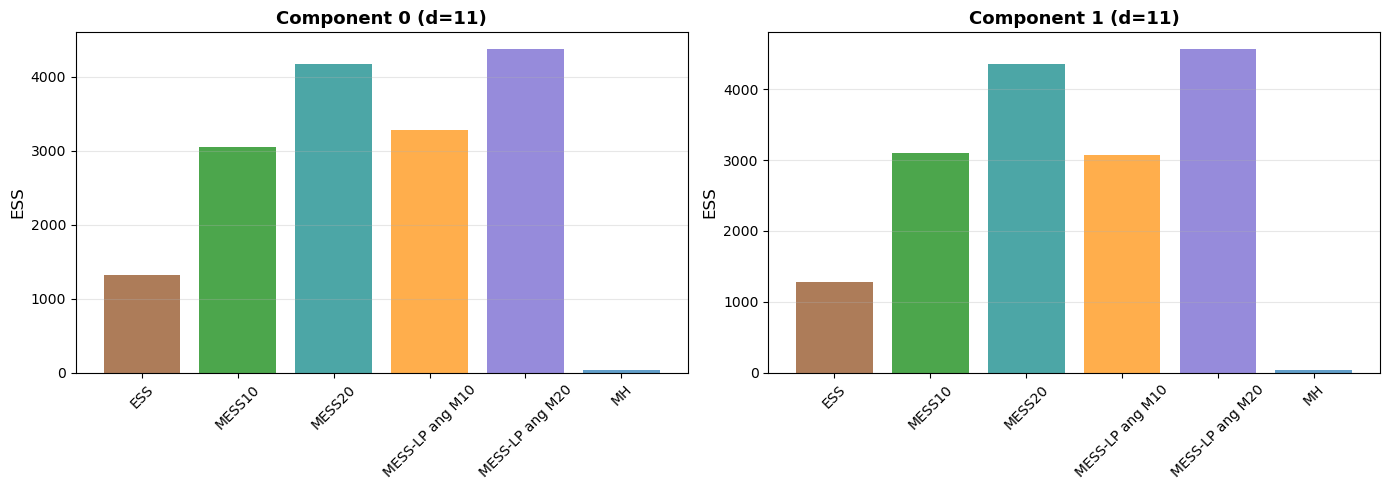

In [114]:
# Component-wise ESS plots for the first two components.
# Load saved chains and compute ESS for components 0 and 1 only.

comp_to_plot = [comps[0], comps[1]]  # First two components from comps
max_lag_comp = 1500

# Use the chains that are already in memory from earlier estimation
post_ess_comp0 = estimate_effective_sample_size(post_chain_ess[:, comp_to_plot[0]:comp_to_plot[0]+1], max_lag=max_lag_comp)
post_ess_comp1 = estimate_effective_sample_size(post_chain_ess[:, comp_to_plot[1]:comp_to_plot[1]+1], max_lag=max_lag_comp)

post_mess_comp0 = estimate_effective_sample_size(post_chain_mess[:, comp_to_plot[0]:comp_to_plot[0]+1], max_lag=max_lag_comp)
post_mess_comp1 = estimate_effective_sample_size(post_chain_mess[:, comp_to_plot[1]:comp_to_plot[1]+1], max_lag=max_lag_comp)

post_mess20_comp0 = estimate_effective_sample_size(post_chain_mess_20[:, comp_to_plot[0]:comp_to_plot[0]+1], max_lag=max_lag_comp)
post_mess20_comp1 = estimate_effective_sample_size(post_chain_mess_20[:, comp_to_plot[1]:comp_to_plot[1]+1], max_lag=max_lag_comp)

post_messlp10_comp0 = estimate_effective_sample_size(post_chain_mess_lp10[:, comp_to_plot[0]:comp_to_plot[0]+1], max_lag=max_lag_comp)
post_messlp10_comp1 = estimate_effective_sample_size(post_chain_mess_lp10[:, comp_to_plot[1]:comp_to_plot[1]+1], max_lag=max_lag_comp)

post_messlp20_comp0 = estimate_effective_sample_size(post_chain_mess_lp20[:, comp_to_plot[0]:comp_to_plot[0]+1], max_lag=max_lag_comp)
post_messlp20_comp1 = estimate_effective_sample_size(post_chain_mess_lp20[:, comp_to_plot[1]:comp_to_plot[1]+1], max_lag=max_lag_comp)

post_mh_comp0 = estimate_effective_sample_size(post_chain_mh[:, comp_to_plot[0]:comp_to_plot[0]+1], max_lag=max_lag_comp)
post_mh_comp1 = estimate_effective_sample_size(post_chain_mh[:, comp_to_plot[1]:comp_to_plot[1]+1], max_lag=max_lag_comp)

# Create two side-by-side plots for components 0 and 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Component 0 plot
ess_data_comp0 = [post_ess_comp0[0], post_mess_comp0[0], post_mess20_comp0[0], post_messlp10_comp0[0], post_messlp20_comp0[0], post_mh_comp0[0]]
labels = ["ESS", "MESS10", "MESS20", "MESS-LP ang M10", "MESS-LP ang M20", "MH"]
colors = ["saddlebrown", "green", "teal", "darkorange", "slateblue", "tab:blue"]

axes[0].bar(labels, ess_data_comp0, color=colors, alpha=0.7)
axes[0].set_ylabel("ESS", fontsize=12)
axes[0].set_title(f"Component {comp_to_plot[0]} (d=11)", fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Component 1 plot
ess_data_comp1 = [post_ess_comp1[0], post_mess_comp1[0], post_mess20_comp1[0], post_messlp10_comp1[0], post_messlp20_comp1[0], post_mh_comp1[0]]
axes[1].bar(labels, ess_data_comp1, color=colors, alpha=0.7)
axes[1].set_ylabel("ESS", fontsize=12)
axes[1].set_title(f"Component {comp_to_plot[1]} (d=11)", fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
fig.savefig("ess_components_0_1.png", dpi=300)

print(f"Component {comp_to_plot[0]} ESS:")
for label, val in zip(labels, ess_data_comp0):
    print(f"  {label}: {val:.1f}")
print(f"\nComponent {comp_to_plot[1]} ESS:")
for label, val in zip(labels, ess_data_comp1):
    print(f"  {label}: {val:.1f}")

In [ ]:
# Component-wise ESS plots across all dimensions from dimension sweep.
# Load chains from dimension sweep and compute ESS for components 0 and 1 for all d.

# Ensure cache paths are set correctly with Ex_ID_1
exp_cache_dir = Path(FileNmBase) / "Ex_ID_1"
mess_chains_cache_path = exp_cache_dir / "dim_sweep_mess_chains.pkl"
mh_chains_cache_path = exp_cache_dir / "dim_sweep_mh_chains.pkl"

# Load MESS chains from cache
if mess_chains_cache_path.exists():
    with mess_chains_cache_path.open("rb") as handle:
        mess_chains_cache = pickle.load(handle)
    mess_chains_dict = mess_chains_cache.get("chains_dict", {})
    print(f"Loaded MESS chains from {mess_chains_cache_path}")
else:
    raise FileNotFoundError(f"MESS chains cache not found at {mess_chains_cache_path}. Run dimension sweep first.")

# Load MH chains from cache
if mh_chains_cache_path.exists():
    with mh_chains_cache_path.open("rb") as handle:
        mh_chains_cache = pickle.load(handle)
    mh_chains_dict = mh_chains_cache.get("chains_dict", {})
    print(f"Loaded MH chains from {mh_chains_cache_path}")
else:
    raise FileNotFoundError(f"MH chains cache not found at {mh_chains_cache_path}. Run dimension sweep first.")

# Components to analyze
comps_to_analyze = [comps[0], comps[1]]
max_lag_sweep = 1500

# Dictionary to store component-wise ESS by M and component
ess_comp_0_by_M = {M: [] for M in M_list}
ess_comp_1_by_M = {M: [] for M in M_list}
ess_comp_0_mh = []
ess_comp_1_mh = []

# Compute component-wise ESS for MESS
print("Computing component-wise ESS for MESS across all dimensions...")
for d_idx, d_cur in enumerate(d_list):
    for M in M_list:
        if (d_idx, M) in mess_chains_dict:
            chain_slice = mess_chains_dict[(d_idx, M)]
            ess_comp0 = estimate_effective_sample_size(chain_slice[:, comps_to_analyze[0]:comps_to_analyze[0]+1], max_lag=max_lag_sweep)
            ess_comp1 = estimate_effective_sample_size(chain_slice[:, comps_to_analyze[1]:comps_to_analyze[1]+1], max_lag=max_lag_sweep)
            ess_comp_0_by_M[M].append(float(np.mean(ess_comp0)))
            ess_comp_1_by_M[M].append(float(np.mean(ess_comp1)))
        else:
            print(f"  WARNING: Missing chain for d={d_cur} (idx={d_idx}), M={M}")

# Compute component-wise ESS for MH
print("Computing component-wise ESS for MH across all dimensions...")
for d_idx in range(len(d_list)):
    if d_idx in mh_chains_dict:
        chain_mh_slice = mh_chains_dict[d_idx]
        ess_comp0_mh = estimate_effective_sample_size(chain_mh_slice[:, comps_to_analyze[0]:comps_to_analyze[0]+1], max_lag=max_lag_sweep)
        ess_comp1_mh = estimate_effective_sample_size(chain_mh_slice[:, comps_to_analyze[1]:comps_to_analyze[1]+1], max_lag=max_lag_sweep)
        ess_comp_0_mh.append(float(np.mean(ess_comp0_mh)))
        ess_comp_1_mh.append(float(np.mean(ess_comp1_mh)))
    else:
        print(f"  WARNING: Missing MH chain for d={d_list[d_idx]} (idx={d_idx})")

# Create plots for component-wise ESS vs dimension
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(M_list)))

# Component 0 plot
for M, color in zip(M_list, colors):
    if len(ess_comp_0_by_M[M]) == len(d_list):
        axes[0].plot(d_list, ess_comp_0_by_M[M], marker="o", color=color, label=f"M={M}")
    else:
        print(f"  WARNING: Skipping incomplete ESS data for component 0, M={M}")
if len(ess_comp_0_mh) == len(d_list):
    axes[0].plot(d_list, ess_comp_0_mh, marker="s", color="black", linestyle="--", label="MH")
axes[0].set_xlabel("Dimension (d)", fontsize=12)
axes[0].set_ylabel("ESS", fontsize=12)
axes[0].set_title(f"Component {comps_to_analyze[0]} - ESS vs Dimension", fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].legend(loc="best", ncol=2)

# Component 1 plot
for M, color in zip(M_list, colors):
    if len(ess_comp_1_by_M[M]) == len(d_list):
        axes[1].plot(d_list, ess_comp_1_by_M[M], marker="o", color=color, label=f"M={M}")
    else:
        print(f"  WARNING: Skipping incomplete ESS data for component 1, M={M}")
if len(ess_comp_1_mh) == len(d_list):
    axes[1].plot(d_list, ess_comp_1_mh, marker="s", color="black", linestyle="--", label="MH")
axes[1].set_xlabel("Dimension (d)", fontsize=12)
axes[1].set_ylabel("ESS", fontsize=12)
axes[1].set_title(f"Component {comps_to_analyze[1]} - ESS vs Dimension", fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].legend(loc="best", ncol=2)

plt.tight_layout()
fig.savefig("ess_components_vs_dimension.png", dpi=300)
print("\nPlot saved as 'ess_components_vs_dimension.png'")

## Dimension Sweep with $M=d$ (Uniform MESS)
We repeat the MSJD vs. $d$ plot using uniform MESS with the number of proposals set equal to the dimension.

Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.


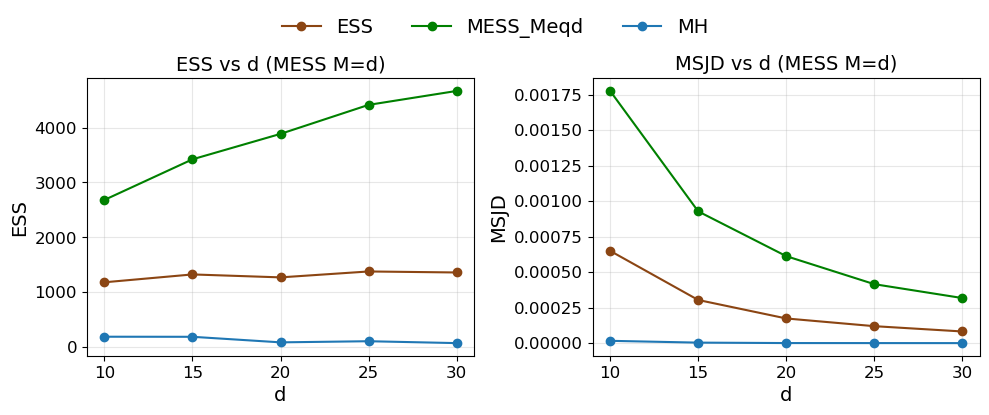

In [19]:
# Dimension sweep with MESS proposals scaled as M=d (uniform distance).
d_list_scaled = [10, 15, 20, 25, 30]
mh_proposal_stds_scaled = [0.012, 0.005, 0.0035, 0.001, 0.0009]
n_iters_dim_scaled = 100000
burn_in_frac_scaled = 0.2
max_lag_scaled = 1500

ess_by_alg_scaled = {"ESS": [], "MESS_Meqd": [], "MH": []}
msjd_by_alg_scaled = {"ESS": [], "MESS_Meqd": [], "MH": []}

for d_cur in d_list_scaled:
    obs_scale_cur = max(3, min(d_cur - 1, 7))
    data_slice_start_cur = obs_scale_cur - 3
    data_slice_end_cur = obs_scale_cur - 1
    obs_indices_cur = np.arange(data_slice_start_cur, data_slice_end_cur, dtype=int)

    data_cur = generate_advection_diffusion_data(
        dim=d_cur,
        kappa=kappa,
        sigma=sigma,
        obs_indices=obs_indices_cur,
        alpha=alpha,
        gamma=gamma,
        tau2=tau2,
        a_mode=a_mode,
        seed=seed_data,
    )
    problem_cur = AdvectionDiffusionToy(
        dim=d_cur,
        kappa=kappa,
        sigma=sigma,
        y=data_cur['y'],
        obs_indices=obs_indices_cur,
        g=data_cur['g'],
        prior_diag=data_cur['prior_diag'],
    )
    x0_cur = data_cur['a_init']
    burn_in_cur = int(burn_in_frac_scaled * n_iters_dim_scaled)

    # ESS
    rng = np.random.default_rng(seed_mcmc)
    chain_cur = np.zeros((n_iters_dim_scaled + 1, x0_cur.shape[0]))
    chain_cur[0] = x0_cur.copy()
    x = x0_cur.copy()
    for t in range(n_iters_dim_scaled):
        x, _, _ = ess_step(x, problem_cur, rng)
        chain_cur[t + 1] = x
    post = chain_cur[burn_in_cur:]
    ess_vals = estimate_effective_sample_size(post, max_lag=max_lag_scaled)
    ess_by_alg_scaled["ESS"].append(float(np.mean(ess_vals)))
    msjd_by_alg_scaled["ESS"].append(float(np.mean(compute_msjd(post))))

    # MESS with M=d_cur (uniform)
    rng = np.random.default_rng(seed_mcmc)
    chain_cur = np.zeros((n_iters_dim_scaled + 1, x0_cur.shape[0]))
    chain_cur[0] = x0_cur.copy()
    x = x0_cur.copy()
    for t in range(n_iters_dim_scaled):
        x, _, _ = mess_step(x, problem_cur, rng, M=d_cur, use_lp=False)
        chain_cur[t + 1] = x
    post = chain_cur[burn_in_cur:]
    ess_vals = estimate_effective_sample_size(post, max_lag=max_lag_scaled)
    ess_by_alg_scaled["MESS_Meqd"].append(float(np.mean(ess_vals)))
    msjd_by_alg_scaled["MESS_Meqd"].append(float(np.mean(compute_msjd(post))))

    # MH
    rng = np.random.default_rng(seed_mcmc)
    mh_proposal_std = mh_proposal_stds_scaled[d_list_scaled.index(d_cur)]
    chain_cur, _ = mh_chain(x0_cur, problem_cur, rng, n_iters_dim_scaled, proposal_std=mh_proposal_std)
    post = chain_cur[burn_in_cur:]
    ess_vals = estimate_effective_sample_size(post, max_lag=max_lag_scaled)
    ess_by_alg_scaled["MH"].append(float(np.mean(ess_vals)))
    msjd_by_alg_scaled["MH"].append(float(np.mean(compute_msjd(post))))

font_size = 14
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for alg, color in [("ESS", "saddlebrown"), ("MESS_Meqd", "green"), ("MH", "tab:blue")]:
    axes[0].plot(d_list_scaled, ess_by_alg_scaled[alg], marker="o", color=color, label=alg)
    axes[1].plot(d_list_scaled, msjd_by_alg_scaled[alg], marker="o", color=color, label=alg)
axes[0].set_title("ESS vs d (MESS M=d)", fontsize=font_size)
axes[0].set_xlabel("d", fontsize=font_size)
axes[0].set_ylabel("ESS", fontsize=font_size)
axes[0].grid(alpha=0.3)
axes[0].tick_params(labelsize=font_size - 2)
axes[1].set_title("MSJD vs d (MESS M=d)", fontsize=font_size)
axes[1].set_xlabel("d", fontsize=font_size)
axes[1].set_ylabel("MSJD", fontsize=font_size)
axes[1].grid(alpha=0.3)
axes[1].tick_params(labelsize=font_size - 2)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.05),
    fontsize=font_size,
 )
plt.tight_layout(rect=[0, 0, 1, 0.95])

In [20]:
fig.savefig("ess_msjd_dimension_uniform.pdf", dpi=600)

## ESS/MESS Time Series and Grid Diagnostics
We save the chain and plot the same diagnostics used in the collaborator notebook.

Number of samples available (ESS): 100001
Number of samples available (MESS): 100001
Number of samples available (mPCN): 100001
Number of samples available (MH): 100001


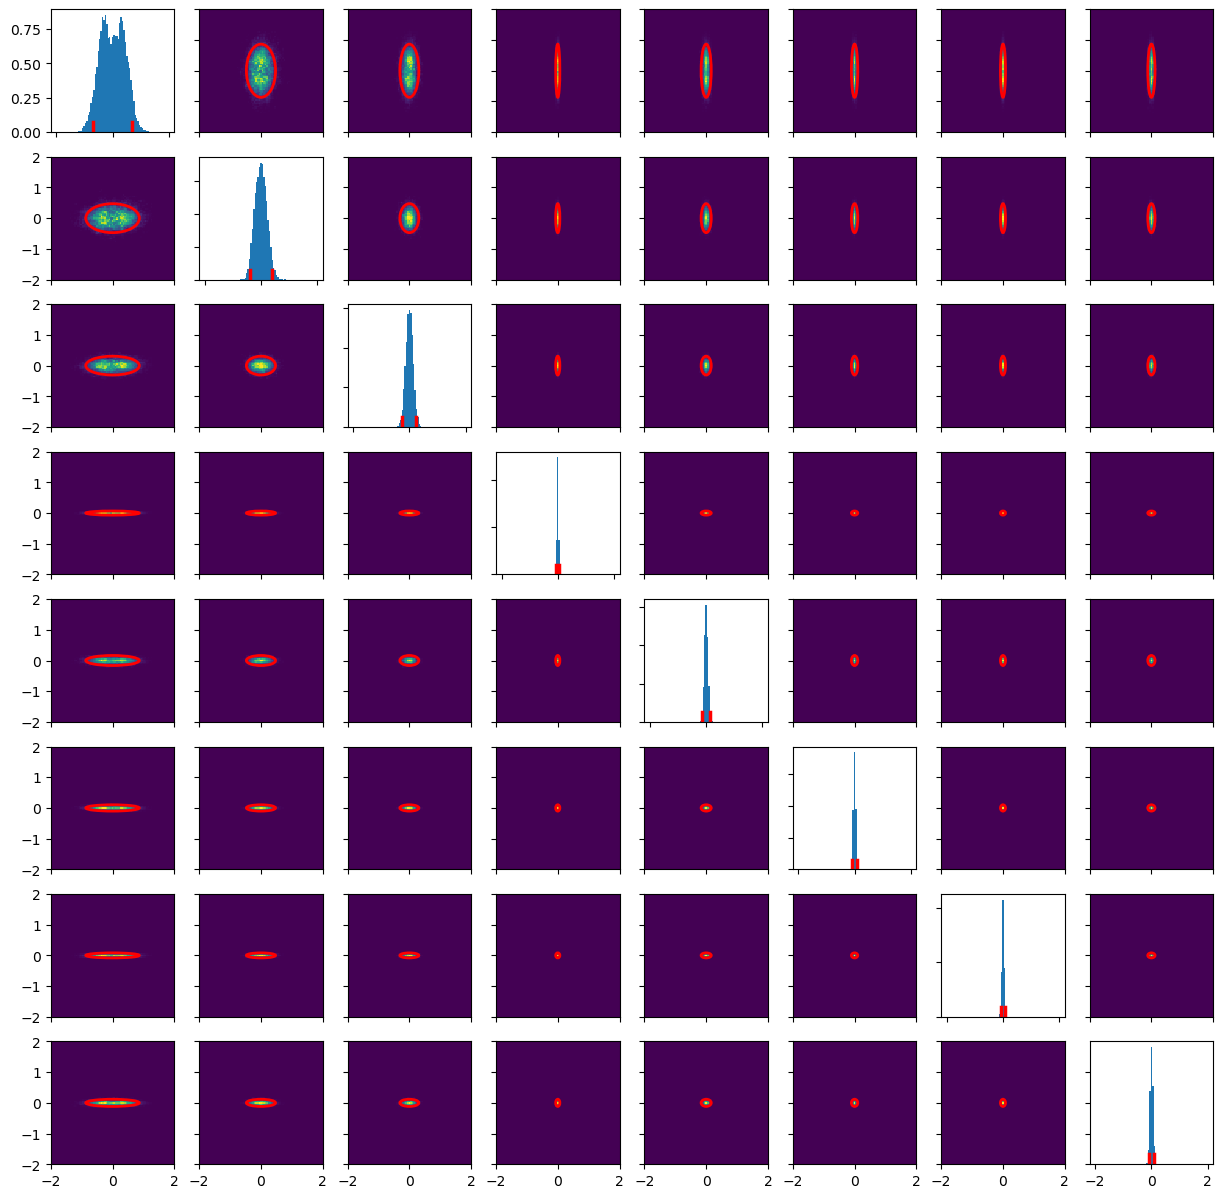

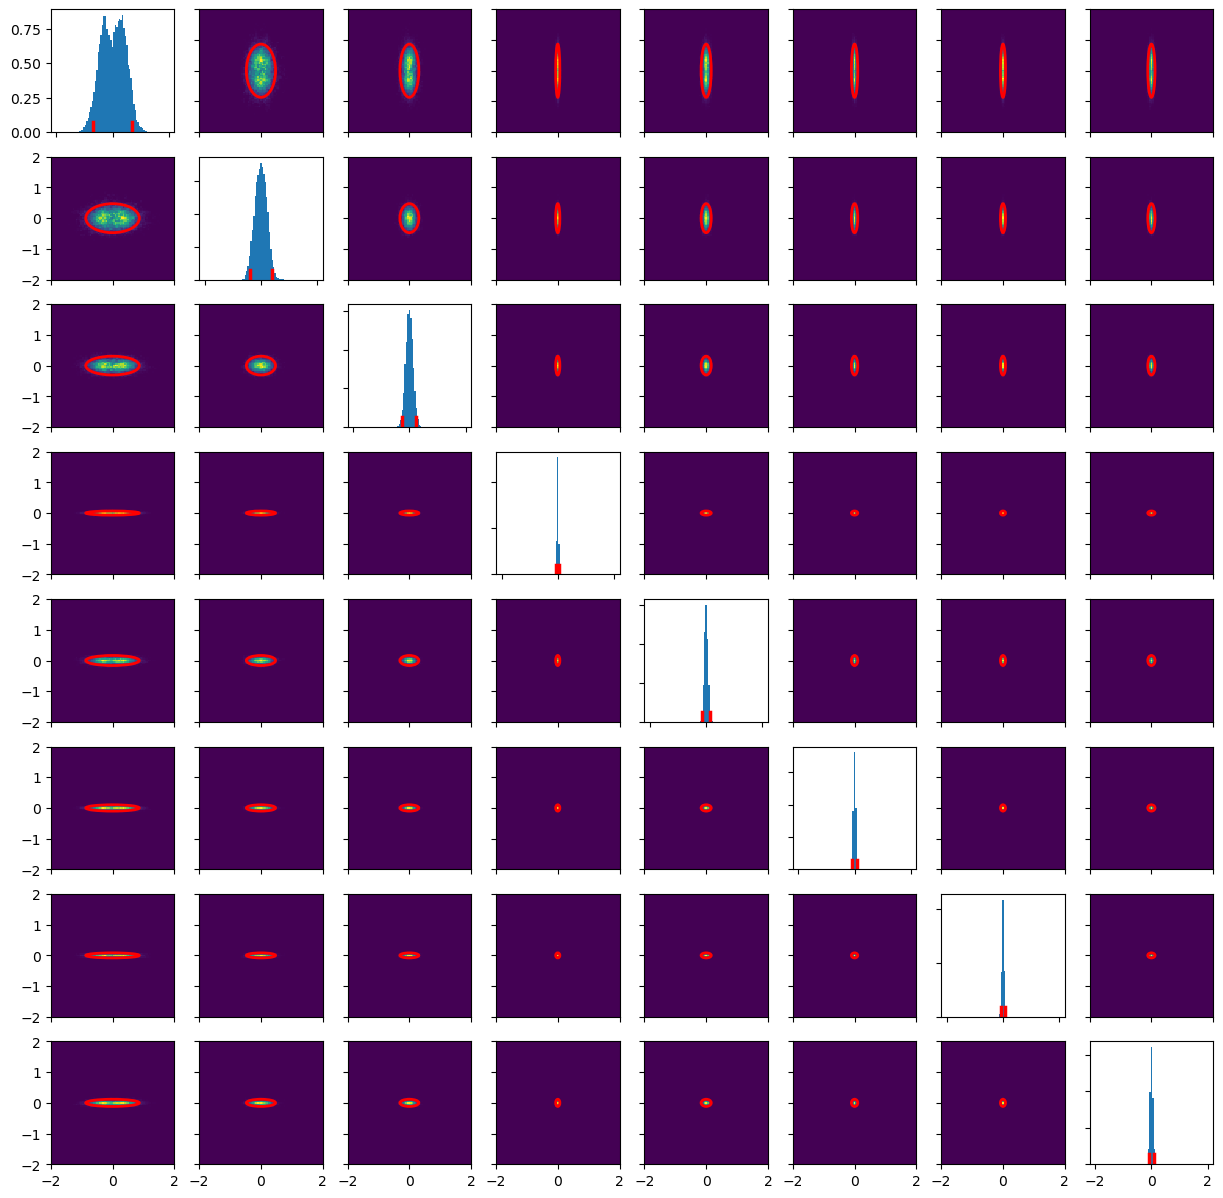

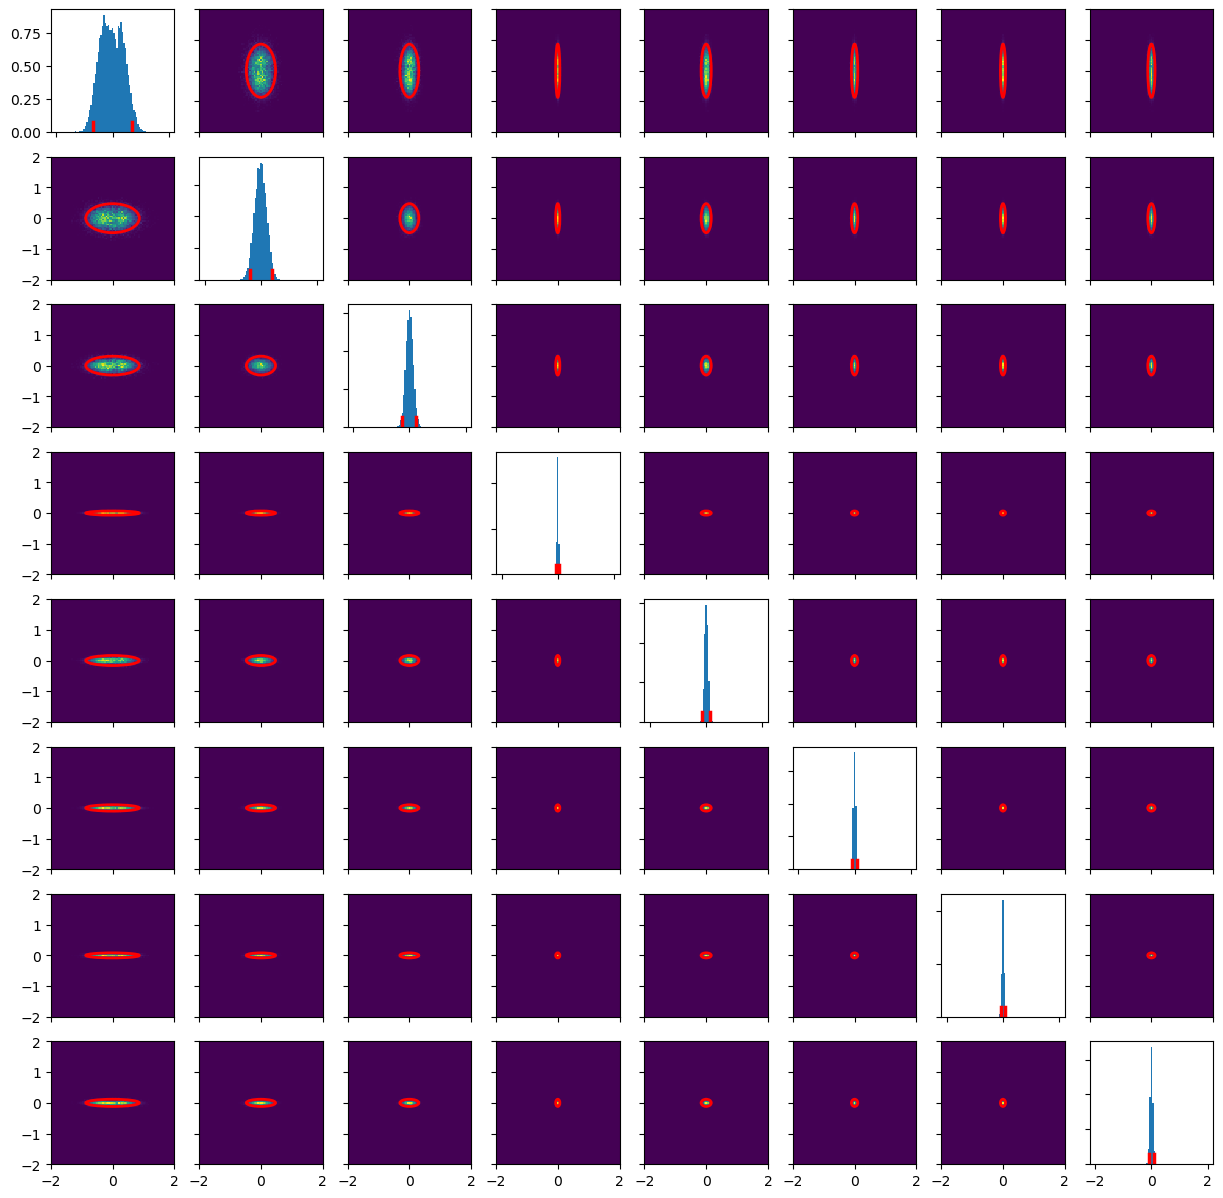

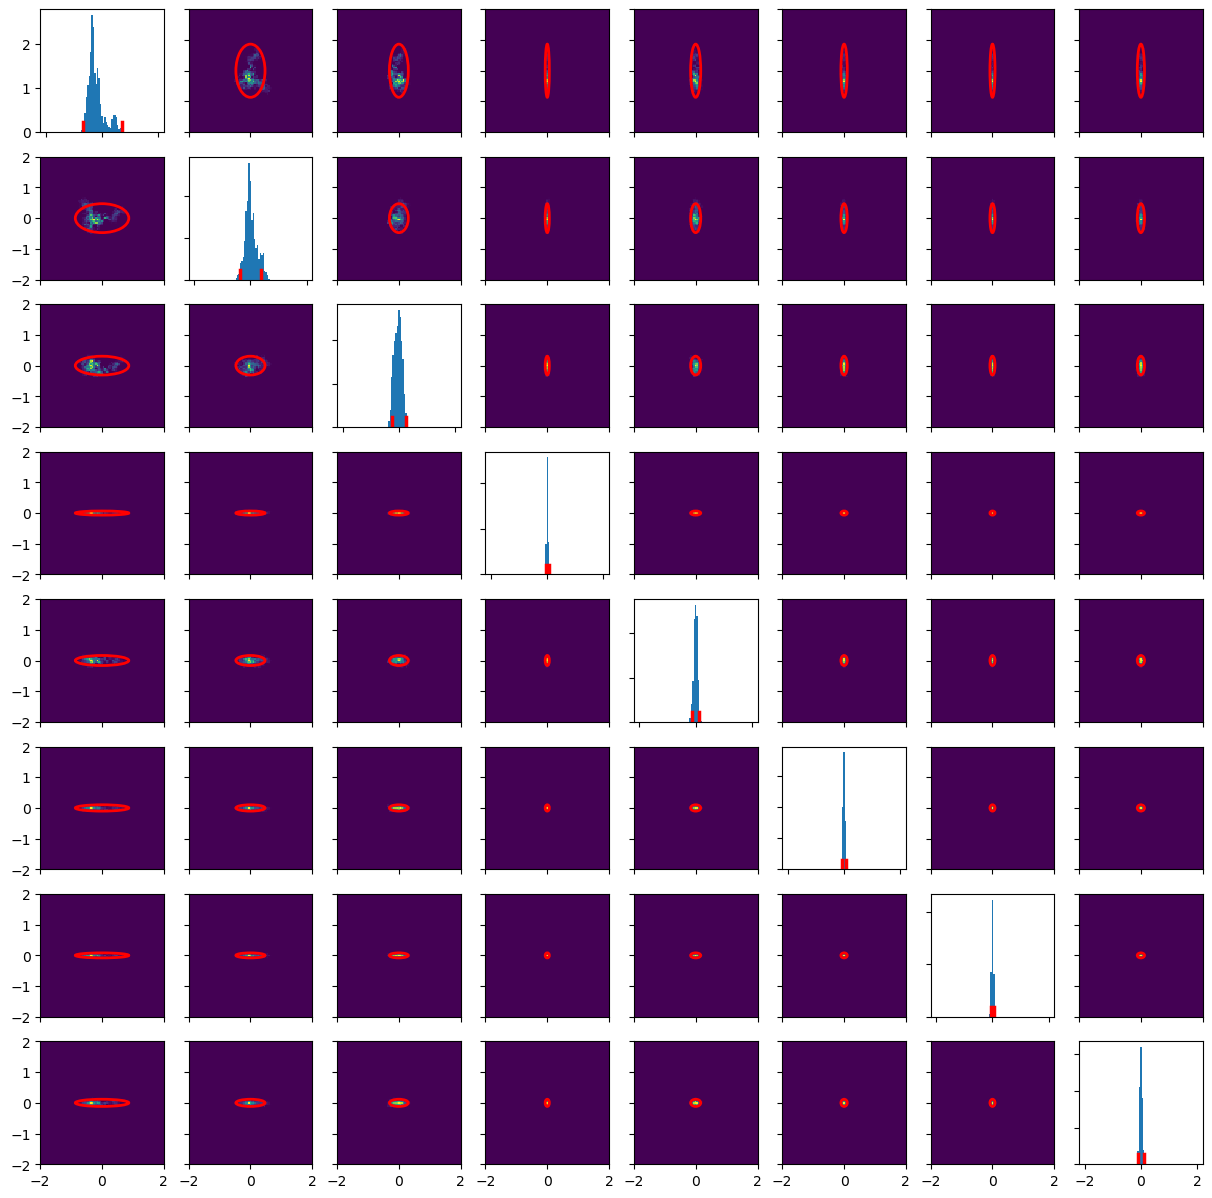

In [ ]:
# Persist results and diagnostics for each chain.
chains = {
    "ESS": chain_ess,
    "MESS10": chain_mess,
    "MESS20": chain_mess_20,
    "MESS_LP10": chain_mess_lp10,
    "MESS_LP20": chain_mess_lp20,
    "MH": chain_mh,
}

# Save runtimes for comparison (seconds).
runtime_file = FileNmBaseData + "runtime_seconds.csv"
with open(runtime_file, "w", encoding="utf-8") as handle:
    handle.write("algorithm,seconds\n")
    for alg, secs in runtimes_sec.items():
        handle.write(f"{alg},{secs:.6f}\n")

for label, est_chain in chains.items():
    est_pot = np.array([-problem.log_likelihood(x) for x in est_chain])
    write_csv(FileNmBaseData + f"exploratory_MCMC_run_{label}.csv", est_chain, new_file=True)
    write_csv(FileNmBaseData + f"exploratory_MCMC_run_Pot_{label}.csv", est_pot[:, None], new_file=True)

    plot_timeseries(est_chain, est_pot, comps, FileNmBase + f"timeseries_{label}.png", label, burn_in)

    numStationarySamps = est_chain.shape[0]
    print(f"Number of samples available ({label}): {numStationarySamps}")

    histFileNm = FileNmBase + f"Baseline_Histogram_{label}.png"
    R = 2 * tau2
    dr = tau2 / 20
    make_hist_grid_comps(R, dr, est_chain, comps, histFileNm, C=CovPriorC3, beta=0.95, hide_plot=False)